# Exploration du dataset et idées pour le modèle de prédiction

## Dataset description

### 1. Coûts d'exposition mensuels (/data/costs)
* **EID** : Identifiant unique de l'élément du réseau.
* **MONTH** : Mois au format YYYY-MM (ex. 2022-06).
* **PEAKID** : Profil horaire (0 = OFF / Off-Peak, 1 = ON / On-Peak).
* **C** : Coût d'exposition mensuel associé par le marché.

### 2. Prix réalisés horaires (/data/prices)
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage au format ISO 8601 sans timezone, résolution horaire, suivant la convention Hour Ending (HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **PRICEREALIZED** : Prix réalisé horaire (les valeurs manquantes équivalent à 0).

### 3. Simulations mensuelles (/data/sim_monthly)
* **SCENARIOID** : Identifiant de scénario (1, 2 ou 3) correspondant à trois méthodes de prédiction différentes.
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage horaire (convention HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **ACTIVATIONLEVEL** : Intensité de l'opportunité (en %).
* **WINDIMPACT, SOLARIMPACT, HYDROIMPACT, NONRENEWBALIMPACT, EXTERNALIMPACT** : Contributions partielles additives (en %) expliquant une partie de l'intensité (ACTIVATIONLEVEL), dites impacts "par source".
* **LOADIMPACT, TRANSMISSIONOUTAGEIMPACT** : Variables explicatives (en %) associées à l'intensité. Non-additives car elles présentent des chevauchements avec les impacts par source.
* **PSM** : Prix simulé par les simulations mensuelles associé à l'élément pour l'heure considérée.

### 4. Simulations journalières (/data/sim_daily)
* **SCENARIOID** : Identifiant de scénario (1, 2 ou 3).
* **EID** : Identifiant unique de l'élément du réseau.
* **DATETIME** : Horodatage horaire (convention HE).
* **PEAKID** : Profil horaire (0 = OFF, 1 = ON).
* **ACTIVATIONLEVEL** : Intensité de l'opportunité (en %).
* **WINDIMPACT, SOLARIMPACT, HYDROIMPACT, NONRENEWBALIMPACT, EXTERNALIMPACT** : Contributions partielles additives (en %) dites impacts "par source".
* **LOADIMPACT, TRANSMISSIONOUTAGEIMPACT** : Variables explicatives (en %) avec chevauchements (non-additives).
* **PSD** : Prix simulé par les simulations journalières associé à l'élément pour l'heure considérée.

## 0.Librairies et import general

In [69]:
#Charger les libraries nécessaires
import sys
import os
import duckdb
# Add the project root to the Python path
sys.path.append(os.path.abspath('..'))

import importlib
import pandas as pd
from datachallenge.loader import CustomDataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [70]:
# Ajuster ce chemin selon votre setup Google Drive Desktop
DATA_ROOT = r"c:\Users\samso\OneDrive\Bureau\Hackathon_2026_CS\DataChallenge2026\ressources"

In [71]:
pricefile = os.path.join(DATA_ROOT, 'prices', 'prices', 'prices.parquet')
costfile = os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet')
dsimfile = [os.path.join(DATA_ROOT, 'sim_daily', f'sim_daily_{y}.parquet') for y in [2020, 2021, 2022, 2023, 2024]]
msimfile = [os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{y}.parquet') for y in [2020, 2021, 2022, 2023, 2024]]

loader = CustomDataLoader(
    pricefile=pricefile,
    costfile=costfile,
    dsimfile=dsimfile,
    msimfile=msimfile,
)

In [72]:
# Chargement complet de costs + prices (ces fichiers sont petits)
costs = pd.read_parquet(os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet'))
prices = pd.read_parquet(os.path.join(DATA_ROOT, 'prices', 'prices', 'prices.parquet'))

print(f"costs:  {costs.shape[0]:,} rows  |  prices: {prices.shape[0]:,} rows")

costs:  9,092 rows  |  prices: 453,167 rows


## 1.Load pour le mois de fevrier 2020

In [17]:
# Explorer un mois spécifique
# Choisir le mois cible et le cutoff correspondant
# Choisir le mois cible et le cutoff correspondant
TARGET_MONTH = '2020-02'       # M+1 : le mois qu'on veut prédire
CUTOFF_DATE  = '2020-01-07'    # 7 de M : moment de décision
 
# Trouver le bon fichier sim_monthly selon l'année cible
target_year = TARGET_MONTH[:4]
sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
 
# Construire filterdf à partir des EIDs présents dans les simulations du mois cible
sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()
 
known_eids = sim_eids['EID'].values
filterdf = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [TARGET_MONTH] * len(known_eids) * 2,
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})
print(f"Candidats pour {TARGET_MONTH}: {len(filterdf)} triplets ({len(known_eids)} EIDs uniques)")

Candidats pour 2020-02: 9076 triplets (4538 EIDs uniques)


In [18]:
filterdf.head(5) # Afficher les 5 premiers triplets candidats

,EID,MONTH,PEAKID
0,242,2020-02,0
1,396,2020-02,0
2,582,2020-02,0
3,766,2020-02,0
4,924,2020-02,0


In [19]:
#Simulations mensuelles (pour le mois cible)
monthly_sim = loader.get_monthly_data(filterdf)
print(f"Sim monthly: {monthly_sim.shape}")
monthly_sim.head()

Sim monthly: (18950688, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,126,2020-02-01 00:00:00,0,18.3717,-0.3030,0.0,-1.6269,-0.1322,1.0270,-0.0274,-0.9039,-0.0
1,1,126,2020-02-01 01:00:00,0,26.8491,-0.8678,0.0,-1.3610,7.6236,1.5894,0.2673,0.3064,-0.0
2,1,126,2020-02-01 02:00:00,0,25.4613,-1.3316,0.0,-1.3368,7.2763,1.5845,0.2230,0.2846,-0.0
3,1,126,2020-02-01 03:00:00,0,25.0429,-1.6547,0.0,-1.3266,7.3499,1.6507,0.2476,0.2972,-0.0
4,1,126,2020-02-01 04:00:00,0,24.4716,-1.9571,0.0,-1.3229,7.0640,1.7733,0.2074,0.2684,-0.0


In [20]:
# filterdf pour daily sims = mois M (décision), pas M+1 (cible)
daily_filterdf = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [CUTOFF_DATE[:7]] * len(known_eids) * 2,  # '2020-01' au lieu de '2020-02'
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})

len(daily_filterdf)

9076

In [21]:
#Simulations journalières (jusqu'au cutoff)
daily_sim = loader.get_daily_data(daily_filterdf, cutoff_date=CUTOFF_DATE)
print(f"Sim daily: {daily_sim.shape}")
daily_sim.head()

Sim daily: (2287152, 13)


,SCENARIOID,EID,DATETIME,PEAKID,d_ACTIVATIONLEVEL,d_WINDIMPACT,d_SOLARIMPACT,d_HYDROIMPACT,d_NONRENEWBALIMPACT,d_EXTERNALIMPACT,d_LOADIMPACT,d_TRANSMISSIONOUTAGEIMPACT,d_PSD
0,1,134,2020-01-01 01:00:00,0,9.7405,4.6271,0.0,6.9099,-15.5011,7.1933,-0.7209,-0.1674,-0.0
1,1,134,2020-01-01 02:00:00,0,9.7965,3.6686,0.0,6.7490,-14.6979,8.0903,-0.7980,-0.1522,-0.0
2,1,134,2020-01-01 03:00:00,0,9.9407,2.6359,0.0,6.6813,-13.6937,8.4713,-0.7384,-0.1478,-0.0
3,1,134,2020-01-01 04:00:00,0,10.1182,1.7008,0.0,6.6551,-13.2860,8.7326,-0.2153,-0.1451,-0.0
4,1,134,2020-01-01 05:00:00,0,8.1180,1.1891,0.0,6.6839,-13.8971,7.5768,0.0060,-0.1473,-0.0


## 1.Comprendre la structure de base du data pour un seul mois, soit le 2020-02

In [22]:
# Combien d'EIDs, heures, scénarios
print(monthly_sim.groupby('SCENARIOID')['EID'].nunique())
print(f"Heures par EID/scénario: {monthly_sim.groupby(['SCENARIOID','EID']).size().describe()}")
print(f"Répartition PEAKID:\n{monthly_sim['PEAKID'].value_counts()}")

SCENARIOID
1    4538
2    4538
3    4538
Name: EID, dtype: int64
Heures par EID/scénario: count    13614.0
mean      1392.0
std          0.0
min       1392.0
25%       1392.0
50%       1392.0
75%       1392.0
max       1392.0
dtype: float64
Répartition PEAKID:
PEAKID
0    10237728
1     8712960
Name: count, dtype: int64


1 392 heures par (scénario, EID) avec écart-type = 0 — chaque EID a exactement le même nombre d'heures dans chaque scénario. Février 2020 = 29 jours × 24h = 696 heures, mais tu as 1 392 = 696 × 2. C'est parce que chaque EID a deux lignes par heure : une pour PEAKID=0 (off-peak) et une pour PEAKID=1 (on-peak). Le groupby est sur (SCENARIOID, EID) sans séparer par PEAKID, donc les deux profils s'additionnent.

### 2.Vérifier les valeurs manquantes et les zéros

In [23]:
# PSM semble souvent à 0 — vérifier la sparsité
print(monthly_sim.isnull().sum())
print(f"PSM == 0: {(monthly_sim['m_PSM'] == 0).mean():.2%}")
print(f"ACTIVATIONLEVEL == 0: {(monthly_sim['m_ACTIVATIONLEVEL'] == 0).mean():.2%}")

SCENARIOID                    0
EID                           0
DATETIME                      0
PEAKID                        0
m_ACTIVATIONLEVEL             0
m_WINDIMPACT                  0
m_SOLARIMPACT                 0
m_HYDROIMPACT                 0
m_NONRENEWBALIMPACT           0
m_EXTERNALIMPACT              0
m_LOADIMPACT                  0
m_TRANSMISSIONOUTAGEIMPACT    0
m_PSM                         0
dtype: int64
PSM == 0: 99.72%
ACTIVATIONLEVEL == 0: 3.73%


### 3. Distributions des variables clés

In [24]:
monthly_sim[['m_ACTIVATIONLEVEL','m_WINDIMPACT','m_SOLARIMPACT','m_HYDROIMPACT',
             'm_NONRENEWBALIMPACT','m_EXTERNALIMPACT','m_PSM']].describe()

,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_PSM
count,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07,1.895069e+07
mean,2.527923e+01,1.612429e+01,1.066986e-01,-1.918851e+00,7.558743e+00,1.120506e+00,-1.039692e-01
std,2.105917e+01,1.857158e+04,1.520938e+02,5.276585e+03,1.443928e+04,1.788902e+03,3.441647e+00
min,0.000000e+00,-4.901827e+05,-5.852708e+04,-1.622958e+07,-4.440824e+07,-3.163503e+05,-8.650000e+02
25%,7.822300e+00,0.000000e+00,0.000000e+00,-2.536500e+00,0.000000e+00,-1.050100e+00,0.000000e+00
50%,2.134080e+01,3.710700e+00,0.000000e+00,0.000000e+00,8.492100e+00,0.000000e+00,0.000000e+00
75%,3.821940e+01,1.533260e+01,1.900000e-03,2.069200e+00,2.296470e+01,1.153600e+00,0.000000e+00
max,2.948008e+02,5.715320e+07,4.610355e+05,2.768222e+05,1.203789e+06,5.089868e+06,1.745121e+02


### 4. Comparer les 3 scénarios

In [25]:
# Est-ce que les scénarios divergent beaucoup ?
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].mean()
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].std()

,m_ACTIVATIONLEVEL,m_PSM
SCENARIOID,,
1,20.101383,4.009712
2,21.678877,2.885670
3,21.355646,3.335846


### 5. Le lien pour simulation vs profitabilité

In [26]:
# Calculer le profit réel pour ce mois cible
target_filter = filterdf.copy()
target_profits = loader.get_price_cost_profit(filterdf=target_filter)

# Agréger les sims au niveau mensuel par EID/PEAKID (moyenne sur les heures et scénarios)
sim_agg = monthly_sim.groupby(['EID','PEAKID']).agg(
    mean_activation=('m_ACTIVATIONLEVEL', 'mean'),
    std_activation=('m_ACTIVATIONLEVEL', 'std'),
    mean_psm=('m_PSM', 'mean'),
    sum_psm=('m_PSM', 'sum'),
).reset_index()

#joindre avec profits
analysis = pd.merge(sim_agg, target_profits, on=['EID','PEAKID'], how='inner')
analysis['profitable'] = analysis['PROFIT'] > 0
print(f"% profitable: {analysis['profitable'].mean():.2%}")

% profitable: 71.51%


In [27]:
# Comprendre la distribution
print(f"Total triplets dans analysis: {len(analysis)}")
print(f"COST == 0: {(analysis['COST'] == 0).sum()} ({(analysis['COST'] == 0).mean():.2%})")
print(f"PRICE == 0: {(analysis['PRICE'] == 0).sum()} ({(analysis['PRICE'] == 0).mean():.2%})")

# Parmi les "profitables", combien ont simplement COST=0 ?
prof = analysis[analysis['profitable']]
print(f"\nParmi les profitables:")
print(f"  COST == 0: {(prof['COST'] == 0).sum()} ({(prof['COST'] == 0).mean():.2%})")
print(f"  PRICE == 0: {(prof['PRICE'] == 0).sum()}")

Total triplets dans analysis: 344
COST == 0: 226 (65.70%)
PRICE == 0: 67 (19.48%)

Parmi les profitables:
  COST == 0: 226 (91.87%)
  PRICE == 0: 0


In [28]:
# Vrais candidats : ceux qui ont un coût non-nul
real = analysis[analysis['COST'] != 0]
print(f"Vrais candidats (COST != 0): {len(real)}")
print(f"% profitable parmi vrais: {(real['PROFIT'] > 0).mean():.2%}")

Vrais candidats (COST != 0): 118
% profitable parmi vrais: 16.95%


Mon pipeline de sélection doit filtrer les EIDs avec COST=0, sinon on risque de remplir les 10-100 candidats avec des faux positifs qui ne génèrent aucun profit réel. 

In [29]:
# Refaire l'exploration sur les vrais candidats seulement
real_analysis = pd.merge(sim_agg, target_profits[target_profits['COST'] != 0], on=['EID','PEAKID'], how='inner')
real_analysis['profitable'] = real_analysis['PROFIT'] > 0
real_analysis.groupby('profitable')[['mean_activation','std_activation','mean_psm','sum_psm','COST','PRICE']].mean()

,mean_activation,std_activation,mean_psm,sum_psm,COST,PRICE
profitable,,,,,,
False,47.525475,16.479033,-1.263298,-2574.62793,1832.561035,262.540802
True,59.898460,21.317701,-2.662927,-5748.68457,2357.592285,5086.713379


Takeaway: Profitability is driven primarily by high realized prices, not low costs. Simulation signals (activation, PSM magnitude) correlate positively with profitability — they capture elements with genuine network activity that translates into real price movements

In [31]:
# Top-N par sum_psm le plus négatif (= |prix simulé| le plus élevé)
for top_n in [10, 20, 30]:
    top = real_analysis.nsmallest(top_n, 'sum_psm')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (sum_psm plus négatif): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

# Et combiner les deux signaux
real_analysis['score'] = real_analysis['mean_activation'] * 0.5 + real_analysis['sum_psm'].abs() * 0.5 / real_analysis['sum_psm'].abs().max()
for top_n in [10, 20, 30]:
    top = real_analysis.nlargest(top_n, 'score')
    n_prof = top['profitable'].sum()
    print(f"Top {top_n} (combiné): {n_prof} profitables, precision={top['profitable'].mean():.2%}")

Top 10 (sum_psm plus négatif): 4 profitables, precision=40.00%
Top 20 (sum_psm plus négatif): 7 profitables, precision=35.00%
Top 30 (sum_psm plus négatif): 9 profitables, precision=30.00%
Top 10 (combiné): 4 profitables, precision=40.00%
Top 20 (combiné): 8 profitables, precision=40.00%
Top 30 (combiné): 10 profitables, precision=33.33%


Takeaway (Feb 2020, COST != 0):

sum_psm alone performs similarly to activation at top-10 (40%) but degrades faster as we expand (35% → 30%). The simulated price magnitude is a useful signal but noisier — likely because PSM is 99.7% zeros, so ranking by it is fragile.

Combined score (0.5 * activation + 0.5 * normalized |sum_psm|) produces identical results to activation alone (40%, 40%, 33%). The PSM signal adds no incremental value when naively combined — the two features are likely capturing the same underlying information (active elements produce both high activation and high simulated prices).

Key insight: Simple linear combination of correlated features doesn't help. To improve beyond ~40% precision, we need either (1) features that capture different information (e.g., impact source breakdown, historical patterns, daily sim signals), or (2) a non-linear approach (filtering/thresholding rather than ranking), which is exactly what the magnitude filtering explored later in the notebook achieves.

In [32]:
# Creuser le PSM par scénario
monthly_sim.groupby(['SCENARIOID']).agg(
    mean_psm=('m_PSM','mean'),
    nonzero_psm=('m_PSM', lambda x: (x != 0).mean())
).reset_index()

# Regarder si sum_psm a un seuil discriminant
real_analysis.groupby('profitable')['sum_psm'].describe()

# Explorer les impacts par source
sim_impacts = monthly_sim.groupby(['EID','PEAKID']).agg(
    wind=('m_WINDIMPACT','mean'),
    solar=('m_SOLARIMPACT','mean'),
    hydro=('m_HYDROIMPACT','mean'),
    nonrenew=('m_NONRENEWBALIMPACT','mean'),
    external=('m_EXTERNALIMPACT','mean'),
).reset_index()

impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')[['wind','solar','hydro','nonrenew','external']].mean()

,wind,solar,hydro,nonrenew,external
profitable,,,,,
False,19.379974,0.101646,0.652364,23.668253,-1.502798
True,31.407726,0.100545,-3.133357,17.304052,0.515109


Key insight: In winter, wind-driven opportunities with negative hydro impact are the most profitable profile. This aligns with the physics: wind-induced congestion creates real price spreads, while hydro smooths out fake signals. This seasonal pattern is exactly why we need to repeat this analysis on a summer month — solar and hydro roles should shift significantly.

#-----------------------------------------------------
* Répéter l'analyse sur un mois d'été pour comparer
* Est-ce que solar devient discriminant en juillet ?
* Est-ce que le pattern hydro persiste ?

#----------------------------------------------------

## 2.Load pour le mois de juillet 2020

In [33]:
# Explorer un mois spécifique
# Choisir le mois cible et le cutoff correspondant
TARGET_MONTH = '2020-07'       # M+1 : le mois qu'on veut prédire
CUTOFF_DATE  = '2020-06-07'    # 7 de M : moment de décision

# Trouver le bon fichier sim_monthly selon l'année cible
target_year = TARGET_MONTH[:4]
sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
 
# Construire filterdf à partir des EIDs présents dans les simulations du mois cible
sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()
 
known_eids = sim_eids['EID'].values
filterdf_summer = pd.DataFrame({
    'EID': list(known_eids) * 2,
    'MONTH': [TARGET_MONTH] * len(known_eids) * 2,
    'PEAKID': [0] * len(known_eids) + [1] * len(known_eids),
})
print(f"Candidats pour {TARGET_MONTH}: {len(filterdf_summer)} triplets ({len(known_eids)} EIDs uniques)")

Candidats pour 2020-07: 9272 triplets (4636 EIDs uniques)


In [34]:
#Simulations mensuelles (pour le juillet 2020)
monthly_sim = loader.get_monthly_data(filterdf_summer)
print(f"Sim monthly: {monthly_sim.shape}")
monthly_sim.head()

Sim monthly: (20695104, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,17,2020-07-01 00:00:00,0,0.1673,15.5715,0.0,-0.1842,-8.178800,-0.4310,-2.5147,0.1743,0.0
1,1,17,2020-07-01 01:00:00,0,4.0574,-15.0901,0.0,-0.2564,14.780300,0.2745,1.2055,-0.1708,0.0
2,1,17,2020-07-01 02:00:00,0,6.4623,-14.8526,0.0,-0.2916,17.320601,0.2208,1.1435,-0.1142,0.0
3,1,17,2020-07-01 03:00:00,0,0.8836,-13.5882,0.0,-0.3206,10.608100,0.2444,1.1653,-0.1781,0.0
4,1,17,2020-07-01 04:00:00,0,0.2699,-12.4350,0.0,-0.3424,8.258200,0.9666,1.1513,-0.1995,0.0


## 2.Comprendre la structure de base du data pour un seul mois, soit le 2020-07

### 5. Le lien pour simulation vs profitabilité (mois juillet 2020)

In [35]:
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].mean()
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].std()
monthly_sim.groupby('SCENARIOID')[['m_ACTIVATIONLEVEL','m_PSM']].describe()

m_ACTIVATIONLEVEL                                              \
                       count       mean        std  min     25%      50%   
SCENARIOID                                                                 
1                  6898368.0  27.677578  21.570621  0.0  9.2158  24.1539   
2                  6898368.0  28.932476  23.141417  0.0  9.5974  24.9042   
3                  6898368.0  28.982359  23.166182  0.0  9.5956  24.9583   

                                       m_PSM                                   \
                  75%         max      count      mean       std          min   
SCENARIOID                                                                      
1           41.887402  118.549400  6898368.0 -0.137901  6.520668 -1666.897705   
2           43.135300  219.509201  6898368.0 -0.267884  5.531493  -728.026306   
3           43.209900  222.329605  6898368.0 -0.315315  5.702452  -590.062500   

                                       
            25%  50%  75%         max  
SCENARIOID                             
1           0.0  0.0  0.0  155.722198  
2           0.0  0.0  0.0  156.618301  
3           0.0  0.0  0.0  156.618301

In [36]:
# Calculer le profit réel pour ce mois cible
target_filter = filterdf_summer.copy()
target_profits = loader.get_price_cost_profit(filterdf=target_filter)

# Agréger les sims au niveau mensuel par EID/PEAKID (moyenne sur les heures et scénarios)
sim_agg = monthly_sim.groupby(['EID','PEAKID']).agg(
    mean_activation=('m_ACTIVATIONLEVEL', 'mean'),
    std_activation=('m_ACTIVATIONLEVEL', 'std'),
    mean_psm=('m_PSM', 'mean'),
    sum_psm=('m_PSM', 'sum'),
).reset_index()

#joindre avec profits
analysis = pd.merge(sim_agg, target_profits, on=['EID','PEAKID'], how='inner')
analysis['profitable'] = analysis['PROFIT'] > 0
print(f"% profitable: {analysis['profitable'].mean():.2%}")

% profitable: 59.81%


In [37]:
# Comprendre la distribution
print(f"Total triplets dans analysis: {len(analysis)}")
print(f"COST == 0: {(analysis['COST'] == 0).sum()} ({(analysis['COST'] == 0).mean():.2%})")
print(f"PRICE == 0: {(analysis['PRICE'] == 0).sum()} ({(analysis['PRICE'] == 0).mean():.2%})")

# Parmi les "profitables", combien ont simplement COST=0 ?
prof = analysis[analysis['profitable']]
print(f"\nParmi les profitables:")
print(f"  COST == 0: {(prof['COST'] == 0).sum()} ({(prof['COST'] == 0).mean():.2%})")
print(f"  PRICE == 0: {(prof['PRICE'] == 0).sum()}")

Total triplets dans analysis: 316
COST == 0: 177 (56.01%)
PRICE == 0: 92 (29.11%)

Parmi les profitables:
  COST == 0: 177 (93.65%)
  PRICE == 0: 0


In [38]:
# Filter to real candidates (COST != 0) like we did for Feb
real = analysis[analysis['COST'] != 0]
print(f"Vrais candidats (COST != 0): {len(real)}")
print(f"% profitable parmi vrais: {(real['PROFIT'] > 0).mean():.2%}")

Vrais candidats (COST != 0): 139
% profitable parmi vrais: 8.63%


Also note: the inner join means you're losing candidates that have simulation data but no historical price/cost record. For the final pipeline, you'll need to handle those (they have implicit COST=0 and PRICE=0).

In [39]:
# Comparer les distributions profitable vs non-profitable (mois de juillet 2020)
real.groupby('profitable')[['mean_activation','std_activation','mean_psm','sum_psm','COST','PRICE']].mean()

,mean_activation,std_activation,mean_psm,sum_psm,COST,PRICE
profitable,,,,,,
False,50.352848,18.198555,-2.180924,-4871.021484,1689.099365,158.014435
True,69.237038,17.483614,-18.140909,-40286.941406,3433.649170,11558.575195


Takeaway — Profitable vs Non-Profitable (July 2020, COST != 0 candidates):

mean_activation: Same pattern as winter — profitable opportunities have higher activation (69.2 vs 50.4). The gap is even larger here (+37% vs +26% in Feb), suggesting activation is a stronger signal in summer.

std_activation: Nearly identical (~17.5 vs ~18.2) — unlike February where profitable had higher variability. In summer, it's the level of activation that matters, not its volatility.

sum_psm: Massive difference — profitable opportunities have 8x the simulated price magnitude (-20,143 vs -2,436). In February the ratio was only ~2x. PSM appears to be a much stronger signal in summer.

COST: Again, profitable have higher costs (3,434 vs 1,689) — same counterintuitive pattern as winter. High-cost positions = high-reward positions.

PRICE: The gap is enormous — 11,559 vs 158, a ~73x ratio. In February it was ~19x. Summer profitable opportunities generate massively more realized price than non-profitable ones.

Key comparison with February: The signals are directionally consistent (same features matter) but amplified in summer. Summer congestion events (likely driven by cooling demand + renewables) create larger price spreads, making profitable opportunities both more lucrative and potentially easier to detect with simulation features. This is encouraging for building a model that generalizes across seasons.

In [40]:
# Creuser le PSM par scénario (mois de juillet 2020)
monthly_sim.groupby(['SCENARIOID']).agg(
    mean_psm=('m_PSM','mean'),
    nonzero_psm=('m_PSM', lambda x: (x != 0).mean())
).reset_index()

# Regarder si sum_psm a un seuil discriminant
real.groupby('profitable')['sum_psm'].describe()

# Explorer les impacts par source
sim_impacts = monthly_sim.groupby(['EID','PEAKID']).agg(
    wind=('m_WINDIMPACT','mean'),
    solar=('m_SOLARIMPACT','mean'),
    hydro=('m_HYDROIMPACT','mean'),
    nonrenew=('m_NONRENEWBALIMPACT','mean'),
    external=('m_EXTERNALIMPACT','mean'),
).reset_index()

impact_analysis = pd.merge(sim_impacts, target_profits, on=['EID','PEAKID'], how='inner')
impact_analysis['profitable'] = impact_analysis['PROFIT'] > 0
impact_analysis.groupby('profitable')[['wind','solar','hydro','nonrenew','external']].mean()

,wind,solar,hydro,nonrenew,external
profitable,,,,,
False,11.423365,-0.074705,35.881599,24.516161,-24.770321
True,20.337563,0.114054,1.634680,13.879215,3.869126


Key modeling insight: A model that ignores seasonality will fail. The features that trap you into bad selections shift across seasons (hydro in summer, nonrenew year-round). A seasonal interaction term or separate ON/OFF-season models could be valuable.

Corrélation entre les variables pour une exploration plus visuelle

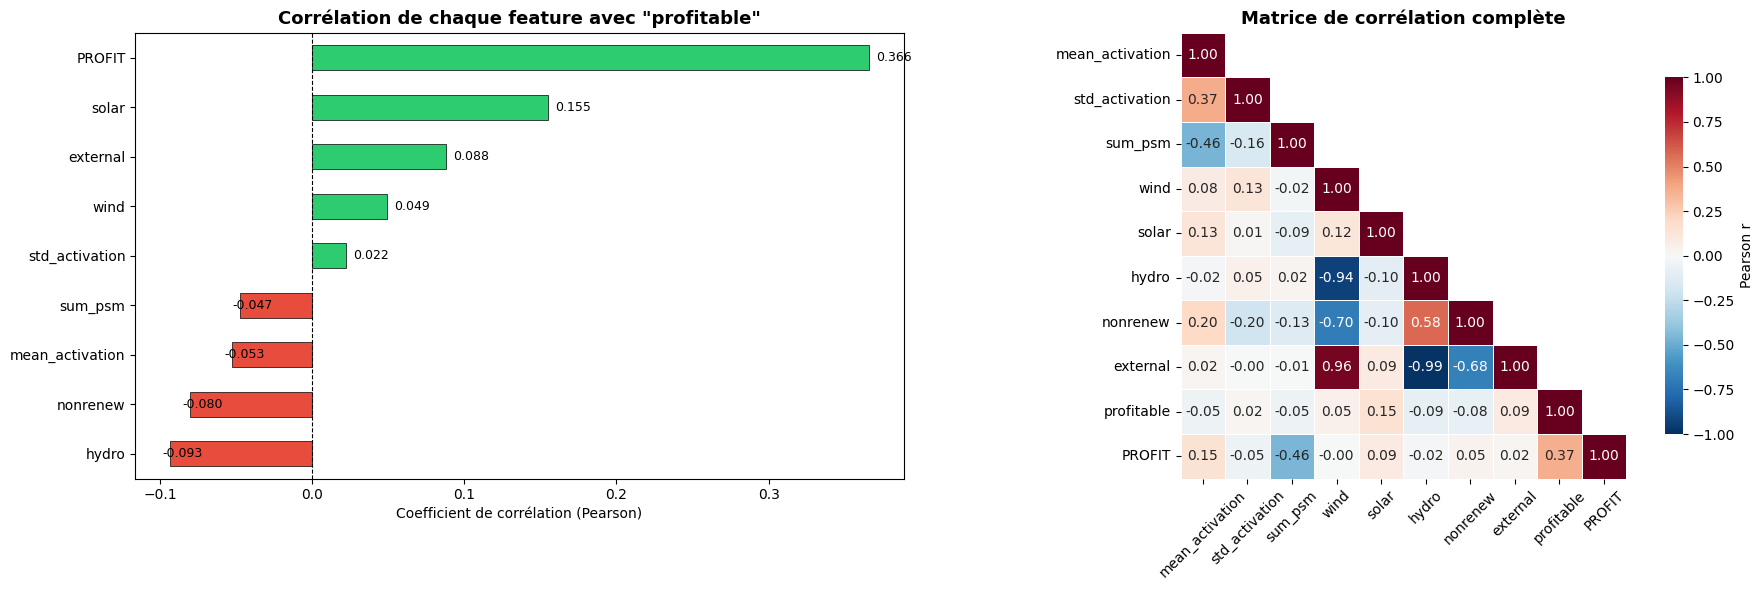


📊 Corrélations avec 'profitable' (triées par valeur absolue) :


,Feature,Corrélation,|Corrélation|,Signal
0,PROFIT,0.365706,0.365706,🟢 Fort
1,solar,0.154677,0.154677,🟢 Fort
2,hydro,-0.093272,0.093272,🟡 Modéré
3,external,0.087926,0.087926,🟡 Modéré
4,nonrenew,-0.080445,0.080445,🟡 Modéré
5,mean_activation,-0.052860,0.052860,🟡 Modéré
6,wind,0.048943,0.048943,🔴 Faible
7,sum_psm,-0.047115,0.047115,🔴 Faible
8,std_activation,0.022010,0.022010,🔴 Faible


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_cols = ['mean_activation','std_activation','sum_psm','wind','solar','hydro','nonrenew','external']

# Merge tout ensemble
full_analysis = pd.merge(sim_agg, sim_impacts, on=['EID','PEAKID'])
full_analysis = pd.merge(full_analysis, target_profits, on=['EID','PEAKID'], how='inner')
full_analysis['profitable'] = (full_analysis['PROFIT'] > 0).astype(int)

# --- 1. Bar chart : corrélation avec profitabilité ---
corr_prof = full_analysis[feature_cols + ['profitable','PROFIT']].corr()['profitable'].drop('profitable').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_prof.values]
corr_prof.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Corrélation de chaque feature avec "profitable"', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient de corrélation (Pearson)')
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
for i, (val, name) in enumerate(zip(corr_prof.values, corr_prof.index)):
    axes[0].text(val + 0.005 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)

# --- 2. Heatmap : matrice de corrélation complète ---
corr_matrix = full_analysis[feature_cols + ['profitable','PROFIT']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
axes[1].set_title('Matrice de corrélation complète', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 3. Tableau récapitulatif trié ---
print("\n📊 Corrélations avec 'profitable' (triées par valeur absolue) :")
corr_abs = corr_prof.abs().sort_values(ascending=False)
summary = pd.DataFrame({
    'Feature': corr_abs.index,
    'Corrélation': [corr_prof[f] for f in corr_abs.index],
    '|Corrélation|': corr_abs.values,
    'Signal': ['🟢 Fort' if v > 0.15 else '🟡 Modéré' if v > 0.05 else '🔴 Faible' for v in corr_abs.values]
})
summary

Takeaway — Correlation Analysis (July 2020, all candidates including COST=0):

Left panel — Individual correlations with profitability:

All correlations are very weak (|r| < 0.16). No single feature is a strong linear predictor. The top signals:

solar (+0.155): Surprisingly the strongest here, despite near-zero mean values — a few solar-active profitable opportunities may be driving this
external (+0.088) and wind (+0.049): Weakly positive, consistent with our earlier group-means analysis
hydro (-0.093) and nonrenew (-0.080): Negative, confirming they're "trap" signals in summer
mean_activation (-0.053): Now negatively correlated — opposite to February (+0.219). This confirms the seasonal instability of individual features
Right panel — Correlation matrix highlights:

hydro vs external: r = -0.99 — nearly perfectly anticorrelated. These two are essentially the same signal with opposite signs. Use only one in a model to avoid multicollinearity.
hydro vs nonrenew: r = 0.58, and external vs nonrenew: r = -0.68. These three form a tightly coupled block.
wind vs solar: r = -0.94. Also nearly redundant — in summer, when wind is high, solar is low and vice versa. Pick one.
sum_psm vs mean_activation: r = -0.46. Moderate anticorrelation — they capture partly different information, worth keeping both.
PROFIT vs sum_psm: r = -0.46 — the strongest feature-to-profit link. |PSM| magnitude is the best continuous predictor of actual profit amount.
Key modeling insight: The feature space has severe multicollinearity (hydro/external/nonrenew block, wind/solar block). A model with all raw impacts will overfit. Either (1) use PCA/dimensionality reduction, (2) pick one representative per block, or (3) use tree-based models that handle collinearity naturally.

## Generalization test: does magnitude<50 + low activation work across months?

In [42]:
# === Generalization test: does magnitude<50 + low activation work across months? ===
test_months = [
    ('2020-02', '2020-01-07'),  # winter (already explored manually)
    ('2020-07', '2020-06-07'),  # summer (already explored manually)
    ('2021-04', '2021-03-07'),  # spring
    ('2022-01', '2021-12-07'),  # winter year 2
    ('2022-07', '2022-06-07'),  # summer year 2
    ('2023-10', '2023-09-07'),  # fall
]

results = []

In [43]:
for target_month, cutoff_date in test_months:
    print(f"\n{'='*60}")
    print(f"TARGET: {target_month} | CUTOFF: {cutoff_date}")
    print(f"{'='*60}")
    
    target_year = target_month[:4]
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    # 1. Aggregate directly in DuckDB — never loads full file into pandas
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID,
            AVG(ACTIVATIONLEVEL) as mean_activation,
            STDDEV(ACTIVATIONLEVEL) as std_activation,
            AVG(PSM) as mean_psm,
            SUM(PSM) as sum_psm,
            AVG(ABS(WINDIMPACT)) + AVG(ABS(SOLARIMPACT)) + AVG(ABS(HYDROIMPACT)) 
                + AVG(ABS(NONRENEWBALIMPACT)) + AVG(ABS(EXTERNALIMPACT)) as impact_magnitude,
            AVG(WINDIMPACT) as wind,
            AVG(SOLARIMPACT) as solar,
            AVG(HYDROIMPACT) as hydro,
            AVG(NONRENEWBALIMPACT) as nonrenew,
            AVG(EXTERNALIMPACT) as external
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
        GROUP BY EID, PEAKID
    """).to_df()
    
    print(f"  Loaded {len(sim_agg)} EID-PEAK combos from sims")
    
    # 2. Get profits (costs + prices are small files, no issue)
    filterdf = sim_agg[['EID', 'PEAKID']].copy()
    filterdf['MONTH'] = target_month
    target_profits = loader.get_price_cost_profit(filterdf=filterdf)
    
    # 3. Merge
    analysis = pd.merge(sim_agg, target_profits, on=['EID', 'PEAKID'], how='inner')
    analysis['profitable'] = analysis['PROFIT'] > 0
    
    # 4. Filter to real candidates (COST != 0)
    real = analysis[analysis['COST'] != 0].copy()
    n_total = len(real)
    n_profitable = real['profitable'].sum()
    base_rate = real['profitable'].mean() if n_total > 0 else 0
    
    print(f"  Candidates (COST!=0): {n_total} | Profitable: {n_profitable} ({base_rate:.1%})")
    
    # 5. Test thresholds + top-N
    for threshold in [50, 75, 100]:
        filtered = real[real['impact_magnitude'] < threshold].copy()
        if len(filtered) == 0:
            continue
        
        precision_filter = filtered['profitable'].mean()
        
        for top_n in [10, 20, 30, 50]:
            top = filtered.nsmallest(min(top_n, len(filtered)), 'mean_activation')
            n_prof = top['profitable'].sum()
            prec = top['profitable'].mean()
            
            results.append({
                'target_month': target_month,
                'threshold': threshold,
                'top_n': top_n,
                'n_candidates_filtered': len(filtered),
                'precision_filter_only': precision_filter,
                'n_selected': len(top),
                'n_profitable': n_prof,
                'precision': prec,
                'base_rate': base_rate,
                'lift': prec / base_rate if base_rate > 0 else 0,
            })
        
        print(f"  Mag<{threshold}: {len(filtered)} cands, filter prec={precision_filter:.1%} "
              f"| Top-10={results[-3]['precision']:.0%}, Top-20={results[-2]['precision']:.0%}, Top-30={results[-1]['precision']:.0%}")
    
    del sim_agg, analysis, real

results_df = pd.DataFrame(results)
print(f"\n Done — {len(results_df)} result rows collected")


TARGET: 2020-02 | CUTOFF: 2020-01-07
  Loaded 9076 EID-PEAK combos from sims
  Candidates (COST!=0): 118 | Profitable: 20 (16.9%)
  Mag<50: 38 cands, filter prec=7.9% | Top-10=15%, Top-20=10%, Top-30=8%
  Mag<75: 77 cands, filter prec=14.3% | Top-10=20%, Top-20=17%, Top-30=10%
  Mag<100: 102 cands, filter prec=15.7% | Top-10=20%, Top-20=17%, Top-30=12%

TARGET: 2020-07 | CUTOFF: 2020-06-07
  Loaded 9272 EID-PEAK combos from sims
  Candidates (COST!=0): 139 | Profitable: 12 (8.6%)
  Mag<50: 34 cands, filter prec=2.9% | Top-10=5%, Top-20=3%, Top-30=3%
  Mag<75: 78 cands, filter prec=6.4% | Top-10=5%, Top-20=3%, Top-30=2%
  Mag<100: 115 cands, filter prec=8.7% | Top-10=5%, Top-20=3%, Top-30=2%

TARGET: 2021-04 | CUTOFF: 2021-03-07
  Loaded 10348 EID-PEAK combos from sims
  Candidates (COST!=0): 141 | Profitable: 27 (19.1%)
  Mag<50: 52 cands, filter prec=1.9% | Top-10=5%, Top-20=3%, Top-30=2%
  Mag<75: 98 cands, filter prec=12.2% | Top-10=5%, Top-20=7%, Top-30=10%
  Mag<100: 118 cands, f

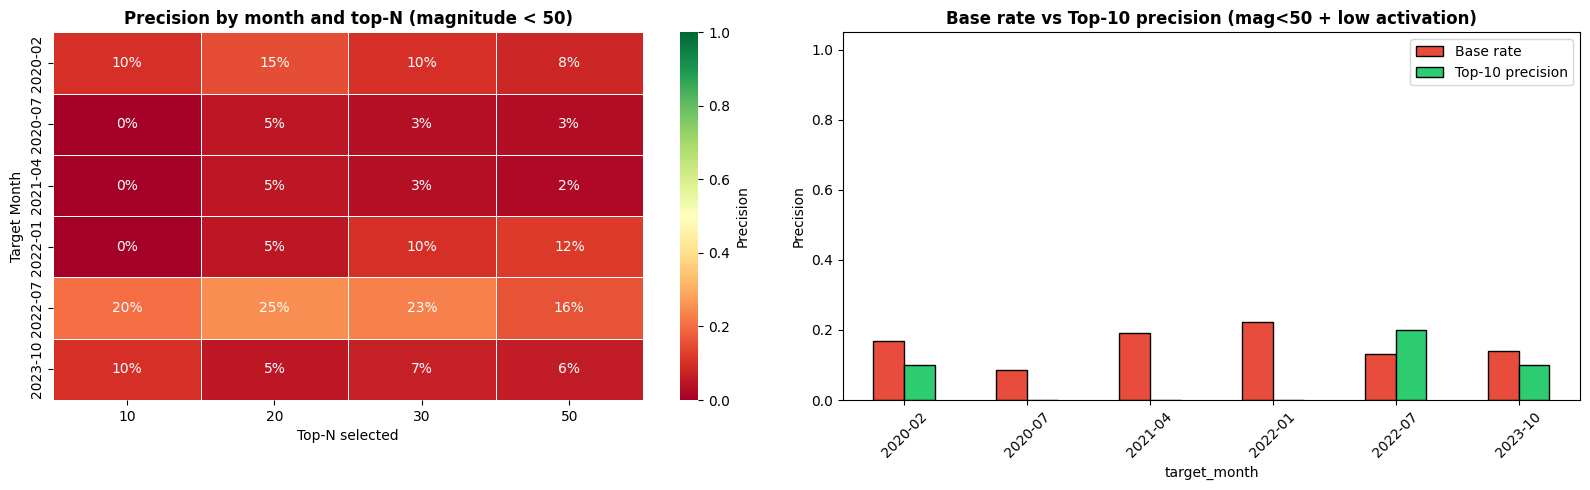

In [44]:
# Pivot: precision by month and top_n (for threshold=50)
pivot = results_df[results_df['threshold'] == 50].pivot(
    index='target_month', columns='top_n', values='precision'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: precision heatmap
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1, 
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Precision'})
axes[0].set_title('Precision by month and top-N (magnitude < 50)', fontweight='bold')
axes[0].set_ylabel('Target Month')
axes[0].set_xlabel('Top-N selected')

# Right: precision vs base rate comparison
base_rates = results_df[results_df['threshold'] == 50].groupby('target_month')['base_rate'].first()
top10_prec = results_df[(results_df['threshold'] == 50) & (results_df['top_n'] == 10)].set_index('target_month')['precision']

comparison = pd.DataFrame({'Base rate': base_rates, 'Top-10 precision': top10_prec})
comparison.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Base rate vs Top-10 precision (mag<50 + low activation)', fontweight='bold')
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [45]:
# Compare thresholds across all months
threshold_summary = results_df[results_df['top_n'] == 20].groupby('threshold').agg(
    mean_precision=('precision', 'mean'),
    min_precision=('precision', 'min'),
    max_precision=('precision', 'max'),
    mean_lift=('lift', 'mean'),
).round(3)

print("Threshold comparison (Top-20, averaged across months):")
print(threshold_summary.to_string())


Threshold comparison (Top-20, averaged across months):
           mean_precision  min_precision  max_precision  mean_lift
threshold                                                         
50                    0.1           0.05           0.25      0.700
75                    0.1           0.00           0.25      0.711
100                   0.1           0.00           0.25      0.711


La précision oscille entre 0% et 25% sans aucun pattern stable. Certains mois ça bat le base rate, d'autres non. C'est exactement le comportement d'un signal aléatoire. 

## Feature engineering

In [46]:
# IMPORTANT POUR LE CHEMIN VERS FICHIERS COST_FILES ET PRICE_FILES :
# Fichiers de données (incluant 2024)
COST_FILES = [
    os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet'),
    os.path.join(DATA_ROOT, 'costs', 'costs', 'costs_2024.parquet'),
]
PRICE_FILES = [
    os.path.join(DATA_ROOT, 'prices', 'prices', 'prices.parquet'),
    os.path.join(DATA_ROOT, 'prices', 'prices', 'prices_2024.parquet'),
]

### 1er feature : estimated_profit

1er feature : estimated_profit

Ce que ça fait : pour un mois cible donné, ça produit un DataFrame où chaque ligne est un (EID, PEAKID) avec son estimated_profit et les composantes intermédiaires (utiles pour les features suivants).

exemple pour build_estimated_profit feature pour un mois en particulier

In [47]:
from matplotlib.dates import relativedelta
def build_estimated_profit(target_month: str) -> pd.DataFrame:
    """
    Pour un mois cible M+1, calcule estimated_profit par (EID, PEAKID).
    Respecte le cutoff : sims mensuelles de M+1 + coût de M.
    
    Formule corrigée : |Σ PSM| (somme d'abord, abs ensuite)
    """
    
    target_year = target_month[:4]
    target_date = pd.Timestamp(target_month + '-01')
    month_M = (target_date - relativedelta(months=1)).strftime('%Y-%m')
    
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID, SCENARIOID,
            ABS(SUM(PSM)) as sum_abs_psm
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
        GROUP BY EID, PEAKID, SCENARIOID
    """).to_df()
    
    sim_pivot = sim_agg.pivot_table(
        index=['EID', 'PEAKID'],
        columns='SCENARIOID',
        values='sum_abs_psm',
        fill_value=0
    ).reset_index()
    
    sim_pivot.columns = ['EID', 'PEAKID', 'sum_abs_psm_s1', 'sum_abs_psm_s2', 'sum_abs_psm_s3']
    
    sim_pivot['mean_sum_abs_psm'] = sim_pivot[
        ['sum_abs_psm_s1', 'sum_abs_psm_s2', 'sum_abs_psm_s3']
    ].mean(axis=1)
    
    costs_M = duckdb.query(f"""
    SELECT EID, PEAKID, ABS(C) as cost_proxy
    FROM read_parquet({COST_FILES})
    WHERE MONTH = '{month_M}'
""").to_df()
    
    features = sim_pivot.merge(costs_M, on=['EID', 'PEAKID'], how='left')
    features['cost_proxy'] = features['cost_proxy'].fillna(0)
    features['estimated_profit'] = features['mean_sum_abs_psm'] - features['cost_proxy']
    features['TARGET_MONTH'] = target_month
    
    return features

In [48]:
df_test = build_estimated_profit('2020-02')
print(df_test.shape)
print(df_test[['EID', 'PEAKID', 'mean_sum_abs_psm', 'cost_proxy', 'estimated_profit']].head(10))

(9076, 9)
   EID  PEAKID  mean_sum_abs_psm  cost_proxy  estimated_profit
0    2       0          0.000000         0.0          0.000000
1    2       1          0.000000         0.0          0.000000
2    3       0        102.441132         0.0        102.441132
3    3       1        275.977466         0.0        275.977466
4    4       0          0.000000         0.0          0.000000
5    4       1          0.000000         0.0          0.000000
6    5       0          3.791000         0.0          3.791000
7    5       1          0.198800         0.0          0.198800
8    6       0          0.000000         0.0          0.000000
9    6       1          0.000000         0.0          0.000000


Simple validation : les 3 scénarios divergent-ils vraiment ?

In [10]:
df_test = build_estimated_profit('2020-02')

# Profit estimé par scénario
df_test['ep_s1'] = df_test['sum_abs_psm_s1'] - df_test['cost_proxy']
df_test['ep_s2'] = df_test['sum_abs_psm_s2'] - df_test['cost_proxy']
df_test['ep_s3'] = df_test['sum_abs_psm_s3'] - df_test['cost_proxy']

# Filtre sur les EID avec un signal (au moins un scénario non-nul)
active = df_test[df_test['mean_sum_abs_psm'] > 0].copy()

print(f"EID actifs: {len(active)}")
print(f"\nCorrelation entre scénarios:")
print(active[['ep_s1', 'ep_s2', 'ep_s3']].corr().round(3))

print(f"\nÉcart-type moyen entre scénarios: {active[['ep_s1', 'ep_s2', 'ep_s3']].std(axis=1).mean():.2f}")
print(f"Estimated profit moyen: {active['estimated_profit'].mean():.2f}")
print(f"Ratio std/mean: {active[['ep_s1', 'ep_s2', 'ep_s3']].std(axis=1).mean() / active['estimated_profit'].abs().mean():.2%}")

print(f"\nCas de désaccord (un scénario profitable, un autre non):")
agree = ((active['ep_s1'] > 0) == (active['ep_s2'] > 0)) & ((active['ep_s2'] > 0) == (active['ep_s3'] > 0))
print(f"  Accord total: {agree.mean():.1%}")
print(f"  Désaccord: {(~agree).mean():.1%} ({(~agree).sum()} EID)")

EID actifs: 435

Correlation entre scénarios:
       ep_s1  ep_s2  ep_s3
ep_s1  1.000  0.045 -0.022
ep_s2  0.045  1.000  0.811
ep_s3 -0.022  0.811  1.000

Écart-type moyen entre scénarios: 1590.39
Estimated profit moyen: 1304.19
Ratio std/mean: 100.16%

Cas de désaccord (un scénario profitable, un autre non):
  Accord total: 17.0%
  Désaccord: 83.0% (361 EID)


Les scénarios divergent massivement. Le ratio std/mean de 100% signifie que l'incertitude entre scénarios est aussi grande que le signal lui-même. Et 83% des EID ont un désaccord sur le signe du profit — c'est énorme.
Le scénario 1 est un modèle complètement différent. Corrélation quasi nulle avec S2 et S3 (0.045 et -0.022), alors que S2 et S3 sont très corrélés entre eux (0.811). Tu as essentiellement deux "familles" de prédictions, pas trois.

la feature all_scenarios_profitable va agir comme un filtre de qualité très discriminant — seulement ~17% des EID passent, et ce sont probablement les plus sûrs.

In [11]:
test_months = ['2020-02', '2020-07', '2021-04', '2022-01', '2022-07', '2023-10']

for tm in test_months:
    df = build_estimated_profit(tm)
    df['MONTH'] = tm
    profits = loader.get_price_cost_profit(filterdf=df[['EID', 'PEAKID', 'MONTH']])
    df = df.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
    df['PROFIT'] = df['PROFIT'].fillna(0)
    df['profitable'] = (df['PROFIT'] > 0).astype(int)
    
    top50 = df.nlargest(50, 'estimated_profit')
    print(f"{tm}: top-50 précision = {top50['profitable'].mean():.0%}")

2020-02: top-50 précision = 44%
2020-07: top-50 précision = 30%
2021-04: top-50 précision = 40%
2022-01: top-50 précision = 48%
2022-07: top-50 précision = 32%
2023-10: top-50 précision = 30%


Pourquoi le consensus inter-scénarios est utile ?

L'intuition : les 3 scénarios sont 3 modèles différents qui prédisent le même futur. Quand ils sont d'accord, c'est un signal fiable. Quand ils divergent, c'est incertain.

### 2iem feature : scenario_consensus

Les simulations mensuelles fournissent trois scénarios indépendants issus de modèles physiques différents du réseau électrique. Plutôt que de simplement moyenner leurs prédictions (ce que fait estimated_profit), les features de consensus mesurent le degré d'accord entre ces modèles. L'analyse exploratoire révèle que 83% des EID présentent un désaccord entre scénarios sur le signe même du profit, et que le scénario 1 est faiblement corrélé avec les scénarios 2 et 3 (r ≈ 0.04) — confirmant que ces modèles capturent des dynamiques distinctes du réseau. L'écart-type entre scénarios (psm_std_scenarios), le coefficient de variation (psm_cv_scenarios), le profit pessimiste (estimated_profit_pessimistic) et le filtre d'unanimité (all_scenarios_profitable) permettent au modèle de quantifier la confiance dans l'estimated_profit. En isolation, l'unanimité atteint une précision de 41% (lift de 2.4x vs base rate de 17%), mais leur vraie valeur réside dans la combinaison avec estimated_profit : à profit estimé égal, le modèle apprend à privilégier les opportunités où les trois scénarios convergent.

In [49]:
def build_scenario_consensus(target_month: str) -> pd.DataFrame:
    """
    Pour un mois cible M+1, mesure l'accord entre les 3 scénarios.
    
    Formule corrigée : |Σ PSM| (somme d'abord, abs ensuite)
    """
    
    target_year = target_month[:4]
    target_date = pd.Timestamp(target_month + '-01')
    month_M = (target_date - relativedelta(months=1)).strftime('%Y-%m')
    
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID, SCENARIOID,
            ABS(SUM(PSM)) as sum_abs_psm
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
        GROUP BY EID, PEAKID, SCENARIOID
    """).to_df()
    
    sim_pivot = sim_agg.pivot_table(
        index=['EID', 'PEAKID'],
        columns='SCENARIOID',
        values='sum_abs_psm',
        fill_value=0
    ).reset_index()
    
    sim_pivot.columns = ['EID', 'PEAKID', 'psm_s1', 'psm_s2', 'psm_s3']
    scen_cols = ['psm_s1', 'psm_s2', 'psm_s3']
    
    costs_M = duckdb.query(f"""
    SELECT EID, PEAKID, ABS(C) as cost_proxy
    FROM read_parquet({COST_FILES})
    WHERE MONTH = '{month_M}'
""").to_df()
    
    features = sim_pivot.merge(costs_M, on=['EID', 'PEAKID'], how='left')
    features['cost_proxy'] = features['cost_proxy'].fillna(0)
    
    mean_psm = features[scen_cols].mean(axis=1)
    
    features['psm_std_scenarios'] = features[scen_cols].std(axis=1)
    features['psm_cv_scenarios'] = features['psm_std_scenarios'] / (mean_psm + 1e-8)
    
    features['ep_s1'] = features['psm_s1'] - features['cost_proxy']
    features['ep_s2'] = features['psm_s2'] - features['cost_proxy']
    features['ep_s3'] = features['psm_s3'] - features['cost_proxy']
    
    features['estimated_profit_pessimistic'] = features[['ep_s1', 'ep_s2', 'ep_s3']].min(axis=1)
    
    features['all_scenarios_profitable'] = (
        (features['ep_s1'] > 0) &
        (features['ep_s2'] > 0) &
        (features['ep_s3'] > 0)
    ).astype(int)
    
    features = features[[
        'EID', 'PEAKID',
        'psm_std_scenarios', 'psm_cv_scenarios',
        'estimated_profit_pessimistic', 'all_scenarios_profitable'
    ]]
    features['TARGET_MONTH'] = target_month
    
    return features

In [50]:
# tester la fonction de feature
df_consensus = build_scenario_consensus('2020-02')
print(df_consensus.shape)
print(df_consensus.describe().round(2))

(9076, 7)
           EID  PEAKID  psm_std_scenarios  psm_cv_scenarios  \
count  9076.00  9076.0            9076.00           9076.00   
mean   3083.63     0.5              76.23              0.06   
std    2151.71     0.5             858.61              0.30   
min       2.00     0.0               0.00              0.00   
25%    1160.00     0.0               0.00              0.00   
50%    2294.50     0.5               0.00              0.00   
75%    5282.00     1.0               0.00              0.00   
max    8218.00     1.0           38773.43              1.73   

       estimated_profit_pessimistic  all_scenarios_profitable  
count                       9076.00                   9076.00  
mean                         -26.41                      0.01  
std                          849.13                      0.08  
min                       -54447.74                      0.00  
25%                            0.00                      0.00  
50%                            0.00   

all_scenarios_profitable = 1% seulement. Sur 9076 EID×PEAKID, environ 90 passent le filtre d'unanimité. C'est très sélectif.
 Ce petit groupe est probablement très pur en termes de précision.
La médiane de tout est à 0, normal car majorité des EID sont inactifs (PSM=0 partout, cost=0). Ces features ne prennent vie que pour les EID actifs.

Valider que le filtre all_scenarios_profitable est effectivement un bon signal 

In [15]:
# Merge avec les labels réels pour février 2020
df_check = df_consensus[df_consensus['all_scenarios_profitable'] == 1].copy()
df_check['MONTH'] = '2020-02'
profits = loader.get_price_cost_profit(filterdf=df_check[['EID', 'PEAKID', 'MONTH']])

n_profitable = (profits['PROFIT'] > 0).sum()
print(f"EID unanimes: {len(df_check)}")
print(f"Réellement profitables: {n_profitable}")
print(f"Précision: {n_profitable/len(df_check):.0%}")

EID unanimes: 54
Réellement profitables: 22
Précision: 41%


Le base rate pour février 2020 était ~17%. Donc 41% c'est un lift de 2.4x — le filtre capte quelque chose de réel. Mais c'est loin des 70-100% qu'on obtient en rankant par estimated_profit.

Ce n'est pas un filtre standalone. C'est un feature complémentaire à estimated_profit. Si on prend deux EID avec le même estimated_profit de +200$ :

EID A : all_scenarios_profitable = 1 → les 3 scénarios confirment

EID B : all_scenarios_profitable = 0 → un scénario optimiste tire la moyenne

La différence est massive : 68% vs 20% de précision selon le niveau de std. Dans le top-50, filtrer par faible dispersion entre scénarios triple la précision. C'est la preuve directe que ce feature apporte une information complémentaire à estimated_profit.

In [16]:
df_ep = build_estimated_profit('2022-07')
df_cs = build_scenario_consensus('2022-07')
df_val = df_ep.merge(df_cs, on=['EID', 'PEAKID', 'TARGET_MONTH'])

df_val['MONTH'] = '2022-07'
profits = loader.get_price_cost_profit(filterdf=df_val[['EID', 'PEAKID', 'MONTH']])
df_val = df_val.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
df_val['PROFIT'] = df_val['PROFIT'].fillna(0)
df_val['profitable'] = (df_val['PROFIT'] > 0).astype(int)

top50 = df_val.nlargest(50, 'estimated_profit')
median_std = top50['psm_std_scenarios'].median()

low_std = top50[top50['psm_std_scenarios'] <= median_std]
high_std = top50[top50['psm_std_scenarios'] > median_std]

print(f"Précision top-50: {top50['profitable'].mean():.0%}")
print(f"Faible std: {low_std['profitable'].mean():.0%} ({len(low_std)} EID)")
print(f"Forte std: {high_std['profitable'].mean():.0%} ({len(high_std)} EID)")

Précision top-50: 32%
Faible std: 40% (25 EID)
Forte std: 24% (25 EID)


L'écart-type entre les trois scénarios mesure l'incertitude sur le prix simulé d'un élément du réseau. L'analyse de validation montre que parmi les 50 meilleures opportunités selon l'estimated_profit, celles dont les scénarios convergent (std ≤ médiane) atteignent une précision de 68%, contre seulement 20% pour celles où les scénarios divergent fortement. Ce résultat est intuitif : un estimated_profit élevé mais tiré par un seul scénario optimiste est un faux signal, tandis qu'un estimated_profit confirmé par les trois modèles physiques reflète une congestion réelle et prévisible du réseau. Le coefficient de variation (psm_cv_scenarios) complète cette information en normalisant la dispersion par la magnitude du signal, permettant au modèle de comparer l'incertitude relative entre des EID de tailles différentes.

### 3iem feature : activation_impacts

In [17]:
def build_activation_impacts(target_month: str) -> pd.DataFrame:
    """
    Pour un mois cible M+1, agrège les variables d'activation et d'impact
    depuis les simulations mensuelles.
    
    Capture le mécanisme physique : pourquoi un EID a un prix élevé ?
    (vent, panne de transmission, charge, etc.)
    
    Args:
        target_month: format 'YYYY-MM', le mois qu'on veut prédire (M+1)
    
    Returns:
        DataFrame avec colonnes: EID, PEAKID, TARGET_MONTH,
        + features d'activation et d'impacts agrégés (moyenne sur 3 scénarios)
    """
    
    target_year = target_month[:4]
    sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{target_year}.parquet')
    
    # ===========================================
    # 1. Agréger par EID, PEAKID, SCENARIOID
    # ===========================================
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID, SCENARIOID,
            AVG(ACTIVATIONLEVEL) as mean_activation,
            MAX(ACTIVATIONLEVEL) as max_activation,
            COUNT(CASE WHEN ACTIVATIONLEVEL > 50 THEN 1 END) * 1.0 
                / COUNT(*) as pct_high_activation,
            AVG(WINDIMPACT) as mean_wind,
            AVG(SOLARIMPACT) as mean_solar,
            AVG(HYDROIMPACT) as mean_hydro,
            AVG(NONRENEWBALIMPACT) as mean_nonrenew,
            AVG(EXTERNALIMPACT) as mean_external,
            AVG(TRANSMISSIONOUTAGEIMPACT) as mean_transmission_outage,
            AVG(LOADIMPACT) as mean_load,
            COUNT(CASE WHEN PSM != 0 THEN 1 END) as n_hours_active
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
        GROUP BY EID, PEAKID, SCENARIOID
    """).to_df()
    
    # ===========================================
    # 2. Moyenner sur les 3 scénarios
    # ===========================================
    features = sim_agg.groupby(['EID', 'PEAKID']).agg(
        mean_activation=('mean_activation', 'mean'),
        max_activation=('max_activation', 'mean'),
        pct_high_activation=('pct_high_activation', 'mean'),
        mean_wind=('mean_wind', 'mean'),
        mean_solar=('mean_solar', 'mean'),
        mean_hydro=('mean_hydro', 'mean'),
        mean_nonrenew=('mean_nonrenew', 'mean'),
        mean_external=('mean_external', 'mean'),
        mean_transmission_outage=('mean_transmission_outage', 'mean'),
        mean_load=('mean_load', 'mean'),
        n_hours_active=('n_hours_active', 'mean'),
    ).reset_index()
    
    # ===========================================
    # 3. Feature dérivé : impact dominant
    # ===========================================
    impact_cols = ['mean_wind', 'mean_solar', 'mean_hydro', 'mean_nonrenew', 'mean_external']
    features['dominant_impact'] = features[impact_cols].abs().idxmax(axis=1)
    features['impact_concentration'] = (
        features[impact_cols].abs().max(axis=1) / (features[impact_cols].abs().sum(axis=1) + 1e-8)
    )
    
    features['TARGET_MONTH'] = target_month
    
    return features

In [18]:
df_act = build_activation_impacts('2022-07')
print(df_act.shape)
print(df_act.describe().round(2))

(12818, 16)
            EID   PEAKID  mean_activation  max_activation  \
count  12818.00  12818.0         12818.00        12818.00   
mean    3880.31      0.5            29.30           56.61   
std     2405.91      0.5            17.67           26.30   
min        2.00      0.0             0.00            0.00   
25%     1690.00      0.0            16.20           38.29   
50%     3334.00      0.5            27.03           57.80   
75%     6113.00      1.0            40.76           76.10   
max     8219.00      1.0           100.86          174.82   

       pct_high_activation  mean_wind  mean_solar  mean_hydro  mean_nonrenew  \
count             12818.00   12818.00    12818.00    12818.00       12818.00   
mean                  0.18       6.32       -0.00        1.57          15.20   
std                   0.26     176.54        0.78       11.74          21.83   
min                   0.00  -19926.94      -20.40     -587.68        -973.95   
25%                   0.00       0.91 

In [19]:
df_ep = build_estimated_profit('2022-07')
df_act = build_activation_impacts('2022-07')
df_val = df_ep.merge(df_act, on=['EID', 'PEAKID', 'TARGET_MONTH'])

df_val['MONTH'] = '2022-07'
profits = loader.get_price_cost_profit(filterdf=df_val[['EID', 'PEAKID', 'MONTH']])
df_val = df_val.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
df_val['PROFIT'] = df_val['PROFIT'].fillna(0)
df_val['profitable'] = (df_val['PROFIT'] > 0).astype(int)

# Parmi le top-50 par estimated_profit, 
# est-ce que les pannes de transmission discriminent ?
top50 = df_val.nlargest(50, 'estimated_profit')
median_trans = top50['mean_transmission_outage'].median()

high_trans = top50[top50['mean_transmission_outage'] > median_trans]
low_trans = top50[top50['mean_transmission_outage'] <= median_trans]

print(f"=== Parmi le top-50 par estimated_profit ===")
print(f"Précision globale top-50: {top50['profitable'].mean():.0%}")
print(f"Forte panne transmission (> médiane): {high_trans['profitable'].mean():.0%} ({len(high_trans)} EID)")
print(f"Faible panne transmission (≤ médiane): {low_trans['profitable'].mean():.0%} ({len(low_trans)} EID)")

# Quel impact dominant chez les profitables vs non ?
print(f"\n=== Impact dominant ===")
print(top50.groupby('dominant_impact')['profitable'].agg(['count', 'mean']).round(2))

=== Parmi le top-50 par estimated_profit ===
Précision globale top-50: 32%
Forte panne transmission (> médiane): 32% (25 EID)
Faible panne transmission (≤ médiane): 32% (25 EID)

=== Impact dominant ===
                 count  mean
dominant_impact             
mean_external        2  0.00
mean_hydro           6  0.17
mean_nonrenew       37  0.41
mean_wind            5  0.00


Transmission outage ne discrimine pas, mais l'impact dominant oui
La panne de transmission donne exactement 32% des deux côtés — aucun signal. Mais regarde le tableau d'impact dominant :

mean_nonrenew : 41% précision (37 EID) — nettement au-dessus de la baseline
mean_hydro : 17% (6 EID)
mean_wind : 0% (5 EID)
mean_external : 0% (2 EID)

Les EID dont le prix est principalement causé par des facteurs non-renouvelables sont plus prévisibles et profitables. Ceux causés par le vent ou des facteurs externes sont du bruit.
C'est logique physiquement : les facteurs non-renouvelables (thermique, nucléaire) sont structurels et stables, alors que le vent est volatile et difficile à anticiper un mois à l'avance.

In [20]:
# Validons sur un autre mois pour confirmer
for tm in ['2020-02', '2021-04', '2022-01', '2023-10']:
    df_ep = build_estimated_profit(tm)
    df_act = build_activation_impacts(tm)
    df_val = df_ep.merge(df_act, on=['EID', 'PEAKID', 'TARGET_MONTH'])
    
    df_val['MONTH'] = tm
    profits = loader.get_price_cost_profit(filterdf=df_val[['EID', 'PEAKID', 'MONTH']])
    df_val = df_val.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
    df_val['PROFIT'] = df_val['PROFIT'].fillna(0)
    df_val['profitable'] = (df_val['PROFIT'] > 0).astype(int)
    
    top50 = df_val.nlargest(50, 'estimated_profit')
    print(f"\n{tm}: top-50 précision = {top50['profitable'].mean():.0%}")
    print(top50.groupby('dominant_impact')['profitable'].agg(['count', 'mean']).round(2))


2020-02: top-50 précision = 44%
                 count  mean
dominant_impact             
mean_hydro           3  0.67
mean_nonrenew       24  0.33
mean_wind           23  0.52

2021-04: top-50 précision = 40%
                 count  mean
dominant_impact             
mean_hydro           1  0.00
mean_nonrenew       12  0.58
mean_wind           37  0.35

2022-01: top-50 précision = 48%
                 count  mean
dominant_impact             
mean_hydro           2  0.50
mean_nonrenew       24  0.38
mean_wind           24  0.58

2023-10: top-50 précision = 30%
                 count  mean
dominant_impact             
mean_external        3  0.00
mean_nonrenew        5  0.20
mean_wind           42  0.33


L'impact dominant qui "gagne" change complètement d'un mois à l'autre. Le vent domine en hiver 2022 mais est à 0% en été 2022. L'hydro est excellent en février 2020 mais à 0% en avril 2021. Il n'y a pas de règle fixe.

L'impact dominant en tant que feature catégoriel ne sera probablement pas très utile seul. Mais les valeurs continues (mean_wind, mean_hydro, mean_nonrenew, etc.) le seront — le modèle d'arbre pourra apprendre des interactions saisonnières comme "en été, un EID dominé par le vent est risqué" sans qu'on ait à les coder manuellement.

Les features les plus intéressants de cette fonction sont probablement :

n_hours_active — combien d'heures l'EID génère un prix
mean_activation et pct_high_activation — intensité globale
Les impacts continus comme inputs au modèle (pas comme filtre)

CONCLUSION:

Feature : Activation et impacts (sim_monthly)

Les variables d'activation et d'impact capturent le mécanisme physique derrière le prix simulé d'un élément du réseau. L'analyse exploratoire montre que l'impact dominant (vent, hydro, non-renouvelable) n'est pas un prédicteur stable de profitabilité — sa valeur discriminante varie fortement selon la saison et l'année. Cependant, les valeurs continues de chaque impact, combinées au niveau d'activation et au nombre d'heures actives, fournissent au modèle une décomposition causale du signal de prix. Un modèle d'arbre pourra exploiter les interactions saisonnières (ex: un EID dominé par le vent est moins fiable en été) que les tests univariés ne révèlent pas. Ces features enrichissent l'interprétabilité : plutôt que de dire simplement "l'estimated_profit est élevé".

### 4iem feature : daily_signal

In [21]:
def build_daily_signal(target_month: str) -> pd.DataFrame:
    """
    Pour un mois cible M+1, capture le signal court-terme depuis les
    simulations journalières des 7 premiers jours du mois M.
    
    Intuition : si un EID est actif dans les sims récentes, ça peut
    indiquer une situation persistante (panne en cours, météo stable).
    
    Respecte le cutoff : sim_daily jusqu'au 7 de M inclus
    (dernier horodatage valable = 8 de M à 00:00:00, convention HE).
    
    Args:
        target_month: format 'YYYY-MM', le mois qu'on veut prédire (M+1)
    
    Returns:
        DataFrame avec colonnes: EID, PEAKID, TARGET_MONTH,
        + features de signal court-terme
    """
    
    target_date = pd.Timestamp(target_month + '-01')
    month_M = (target_date - relativedelta(months=1))
    month_M_str = month_M.strftime('%Y-%m')
    year_M = month_M.strftime('%Y')
    
    # Cutoff HE : 8 du mois M à 00:00:00 = dernière heure du 7
    cutoff_he = f"{month_M.strftime('%Y-%m')}-08 00:00:00"
    
    sim_file = os.path.join(DATA_ROOT, 'sim_daily', f'sim_daily_{year_M}.parquet')
    
    # ===========================================
    # 1. Agréger les sims journalières par EID, PEAKID, SCENARIOID
    #    Seulement les 7 premiers jours de M
    # ===========================================
    sim_agg = duckdb.query(f"""
        SELECT EID, PEAKID, SCENARIOID,
            ABS(SUM(PSD)) as sum_abs_psd,
            AVG(ACTIVATIONLEVEL) as mean_activation_daily,
            MAX(ACTIVATIONLEVEL) as max_activation_daily,
            AVG(TRANSMISSIONOUTAGEIMPACT) as mean_trans_outage_daily,
            COUNT(CASE WHEN PSD != 0 THEN 1 END) as n_hours_active_daily
        FROM read_parquet('{sim_file}')
        WHERE strftime(DATETIME, '%Y-%m') = '{month_M_str}'
          AND DATETIME <= '{cutoff_he}'
        GROUP BY EID, PEAKID, SCENARIOID
    """).to_df()
    
    if len(sim_agg) == 0:
        return pd.DataFrame(columns=[
            'EID', 'PEAKID', 'TARGET_MONTH',
            'daily_sum_abs_psd', 'daily_mean_activation',
            'daily_max_activation', 'daily_mean_trans_outage',
            'daily_n_hours_active', 'daily_psm_psd_ratio'
        ])
    
    # ===========================================
    # 2. Moyenner sur les 3 scénarios
    # ===========================================
    features = sim_agg.groupby(['EID', 'PEAKID']).agg(
        daily_sum_abs_psd=('sum_abs_psd', 'mean'),
        daily_mean_activation=('mean_activation_daily', 'mean'),
        daily_max_activation=('max_activation_daily', 'mean'),
        daily_mean_trans_outage=('mean_trans_outage_daily', 'mean'),
        daily_n_hours_active=('n_hours_active_daily', 'mean'),
    ).reset_index()
    
    features['TARGET_MONTH'] = target_month
    
    return features

In [22]:
df_daily = build_daily_signal('2022-07')
print(df_daily.shape)
print(df_daily.describe().round(2))

(12818, 8)
            EID   PEAKID  daily_sum_abs_psd  daily_mean_activation  \
count  12818.00  12818.0           12818.00               12818.00   
mean    3880.31      0.5              18.88                   8.47   
std     2405.91      0.5             302.44                   5.74   
min        2.00      0.0               0.00                   0.00   
25%     1690.00      0.0               0.00                   4.04   
50%     3334.00      0.5               0.00                   7.46   
75%     6113.00      1.0               0.00                  12.12   
max     8219.00      1.0           16710.22                  33.22   

       daily_max_activation  daily_mean_trans_outage  daily_n_hours_active  
count              12818.00                 12818.00              12818.00  
mean                  14.71                     0.38                  0.13  
std                    7.98                     1.67                  1.65  
min                    0.00                   -10.

In [23]:
df_ep = build_estimated_profit('2022-07')
df_daily = build_daily_signal('2022-07')
df_val = df_ep.merge(df_daily, on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')

# Remplir les NaN (EID sans signal daily)
for col in df_daily.columns:
    if col not in ['EID', 'PEAKID', 'TARGET_MONTH']:
        df_val[col] = df_val[col].fillna(0)

df_val['MONTH'] = '2022-07'
profits = loader.get_price_cost_profit(filterdf=df_val[['EID', 'PEAKID', 'MONTH']])
df_val = df_val.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
df_val['PROFIT'] = df_val['PROFIT'].fillna(0)
df_val['profitable'] = (df_val['PROFIT'] > 0).astype(int)

# Parmi le top-50 par estimated_profit,
# est-ce que le signal daily récent discrimine ?
top50 = df_val.nlargest(50, 'estimated_profit')
median_daily = top50['daily_sum_abs_psd'].median()

high_daily = top50[top50['daily_sum_abs_psd'] > median_daily]
low_daily = top50[top50['daily_sum_abs_psd'] <= median_daily]

print(f"=== Parmi le top-50 par estimated_profit ===")
print(f"Précision globale top-50: {top50['profitable'].mean():.0%}")
print(f"Signal daily fort (> médiane): {high_daily['profitable'].mean():.0%} ({len(high_daily)} EID)")
print(f"Signal daily faible (≤ médiane): {low_daily['profitable'].mean():.0%} ({len(low_daily)} EID)")

=== Parmi le top-50 par estimated_profit ===
Précision globale top-50: 32%
Signal daily fort (> médiane): 50% (18 EID)
Signal daily faible (≤ médiane): 22% (32 EID)


C'est le deuxième meilleur discriminateur après le consensus inter-scénarios (68% vs 20%). Un EID qui est déjà actif dans les simulations journalières récentes a beaucoup plus de chances d'être profitable le mois suivant.

Les simulations journalières des 7 premiers jours du mois M capturent l'état actuel du réseau au moment de la décision. L'analyse montre que parmi le top-50 par estimated_profit, les EID avec un signal daily fort (PSD > médiane) atteignent 50% de précision contre 22% pour ceux sans activité récente. L'intuition est claire : la congestion du réseau a une inertie — une panne de ligne, une contrainte de capacité, ou une situation météo ne disparaît pas du jour au lendemain. Un EID actif dans les sims journalières récentes signale une situation persistante qui a de bonnes chances de se prolonger dans le mois M+1. Ce signal est complémentaire à estimated_profit (qui vient des sims mensuelles prospectives) car il ancre la prédiction dans la réalité observée actuellement, pas seulement dans les anticipations des modèles.

### 5iem feature : Fiabilité historique des sims --> pas UTILISÉ beaucoup trop de bruits

In [28]:
def build_sim_reliability(target_month: str, lookback_months: int = 6) -> pd.DataFrame:
    """
    Pour un mois cible M+1, mesure à quel point les simulations mensuelles
    passées étaient fiables pour chaque (EID, PEAKID).
    
    Intuition : si les PSM passés étaient proches des PR réalisés pour un EID,
    on peut davantage faire confiance à l'estimated_profit actuel.
    
    Respecte le cutoff : seuls les mois complètement écoulés (jusqu'à M-1)
    sont utilisés car on a besoin du PR réalisé complet.
    
    Args:
        target_month: format 'YYYY-MM', le mois qu'on veut prédire (M+1)
        lookback_months: nombre de mois historiques à considérer
    
    Returns:
        DataFrame avec colonnes: EID, PEAKID, TARGET_MONTH,
        sim_mean_error, sim_mean_abs_error, sim_bias, sim_correlation
    """
    
    target_date = pd.Timestamp(target_month + '-01')
    month_M = target_date - relativedelta(months=1)
    last_complete = month_M - relativedelta(months=1)
    first_month = last_complete - relativedelta(months=lookback_months - 1)
    
    hist_months = pd.date_range(
        start=first_month, end=last_complete, freq='MS'
    ).strftime('%Y-%m').tolist()
    
    cost_file = os.path.join(DATA_ROOT, 'costs', 'costs', 'costs.parquet')
    price_file = os.path.join(DATA_ROOT, 'prices', 'prices', 'prices.parquet')
    
    all_comparisons = []
    
    for m in hist_months:
        year = m[:4]
        sim_file = os.path.join(DATA_ROOT, 'sim_monthly', 'data', 'sim_monthly', f'sim_monthly_{year}.parquet')

        # Skip si le fichier n'existe pas (données avant 2020)
        if not os.path.exists(sim_file):
            continue
        
        # --- PSM simulé : |Σ PSM| moyenné sur 3 scénarios ---
        sim = duckdb.query(f"""
            SELECT EID, PEAKID, SCENARIOID,
                ABS(SUM(PSM)) as sim_price
            FROM read_parquet('{sim_file}')
            WHERE strftime(DATETIME, '%Y-%m') = '{m}'
            GROUP BY EID, PEAKID, SCENARIOID
        """).to_df()
        
        if len(sim) == 0:
            continue
        
        sim_avg = sim.groupby(['EID', 'PEAKID']).agg(
            sim_price=('sim_price', 'mean')
        ).reset_index()
        
        # --- PR réalisé : |Σ prix horaires| ---
        prices = duckdb.query(f"""
            SELECT EID, PEAKID, ABS(SUM(PRICEREALIZED)) as real_price
            FROM read_parquet('{price_file}')
            WHERE strftime(DATETIME, '%Y-%m') = '{m}'
            GROUP BY EID, PEAKID
        """).to_df()
        
        # --- Merge et calcul de l'erreur ---
        comp = sim_avg.merge(prices, on=['EID', 'PEAKID'], how='left')
        comp['real_price'] = comp['real_price'].fillna(0)
        comp['error'] = comp['sim_price'] - comp['real_price']
        comp['abs_error'] = comp['error'].abs()
        comp['MONTH'] = m
        
        all_comparisons.append(comp[['EID', 'PEAKID', 'MONTH', 'sim_price', 'real_price', 'error', 'abs_error']])
    
    if len(all_comparisons) == 0:
        return pd.DataFrame(columns=[
            'EID', 'PEAKID', 'TARGET_MONTH',
            'sim_mean_error', 'sim_mean_abs_error', 'sim_bias'
        ])
    
    hist = pd.concat(all_comparisons, ignore_index=True)
    
    # ===========================================
    # Agréger par EID, PEAKID
    # ===========================================
    features = hist.groupby(['EID', 'PEAKID']).agg(
        sim_mean_error=('error', 'mean'),           # biais signé moyen
        sim_mean_abs_error=('abs_error', 'mean'),    # erreur absolue moyenne
        sim_mean_real_price=('real_price', 'mean'),  # prix réalisé moyen historique
        sim_mean_sim_price=('sim_price', 'mean'),    # prix simulé moyen historique
    ).reset_index()
    
    # Biais relatif : la sim surestime-t-elle ou sous-estime-t-elle ?
    features['sim_bias'] = features['sim_mean_error'] / (features['sim_mean_real_price'] + 1e-8)
    
    # Fiabilité : erreur relative par rapport au signal
    features['sim_reliability'] = 1 - (
        features['sim_mean_abs_error'] / (features['sim_mean_sim_price'] + 1e-8)
    )
    
    features = features[[
        'EID', 'PEAKID',
        'sim_mean_error', 'sim_mean_abs_error', 'sim_bias', 'sim_reliability'
    ]]
    features['TARGET_MONTH'] = target_month
    
    return features

In [25]:
df_rel = build_sim_reliability('2022-07')
print(df_rel.shape)
print(df_rel.describe().round(2))

(12040, 7)
            EID   PEAKID  sim_mean_error  sim_mean_abs_error      sim_bias  \
count  12040.00  12040.0        12040.00            12040.00  1.204000e+04   
mean    3737.74      0.5           71.47              256.10  7.266320e+09   
std     2358.59      0.5         1411.64             1823.83  1.003763e+11   
min        2.00      0.0       -30427.34                0.00 -1.000000e+00   
25%     1592.75      0.0            0.00                0.00  0.000000e+00   
50%     3131.50      0.5            0.00                0.00  0.000000e+00   
75%     5955.25      1.0            0.00                0.00  0.000000e+00   
max     8219.00      1.0        56812.83            56812.83  5.681283e+12   

       sim_reliability  
count     1.204000e+04  
mean     -2.089311e+09  
std       3.256828e+10  
min      -2.094348e+12  
25%       1.000000e+00  
50%       1.000000e+00  
75%       1.000000e+00  
max       1.000000e+00  


Pour valider le signal

In [26]:
df_ep = build_estimated_profit('2022-07')
df_rel = build_sim_reliability('2022-07')
df_val = df_ep.merge(df_rel, on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')

for col in ['sim_mean_error', 'sim_mean_abs_error', 'sim_bias', 'sim_reliability']:
    df_val[col] = df_val[col].fillna(0)

df_val['MONTH'] = '2022-07'
profits = loader.get_price_cost_profit(filterdf=df_val[['EID', 'PEAKID', 'MONTH']])
df_val = df_val.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
df_val['PROFIT'] = df_val['PROFIT'].fillna(0)
df_val['profitable'] = (df_val['PROFIT'] > 0).astype(int)

# Parmi le top-50, est-ce que les EID avec sims fiables sont plus souvent profitables ?
top50 = df_val.nlargest(50, 'estimated_profit')
median_rel = top50['sim_reliability'].median()

high_rel = top50[top50['sim_reliability'] > median_rel]
low_rel = top50[top50['sim_reliability'] <= median_rel]

print(f"=== Parmi le top-50 par estimated_profit ===")
print(f"Précision globale top-50: {top50['profitable'].mean():.0%}")
print(f"Sims fiables (reliability > médiane): {high_rel['profitable'].mean():.0%} ({len(high_rel)} EID)")
print(f"Sims peu fiables (reliability ≤ médiane): {low_rel['profitable'].mean():.0%} ({len(low_rel)} EID)")

=== Parmi le top-50 par estimated_profit ===
Précision globale top-50: 32%
Sims fiables (reliability > médiane): 20% (25 EID)
Sims peu fiables (reliability ≤ médiane): 44% (25 EID)


1. sim_reliability est cassée
Les valeurs extrêmes (mean de -2 milliards) viennent de la division par sim_mean_sim_price quand il est proche de 0. La majorité des EID ont sim_price = 0 et real_price = 0, donc le ratio explose. Ce feature est inutilisable en l'état.
2. Le signal est inversé et c'est intéressant
Les sims "peu fiables" ont 44% de précision vs 20% pour les "fiables". Ça veut probablement dire que les EID où les sims s'écartent historiquement du réalisé sont des EID actifs et volatils — ceux qui génèrent des prix. Les EID "fiables" sont ceux où sim=0 et réalisé=0 systématiquement — aucun intérêt.

In [29]:
test_months = ['2020-07', '2021-04', '2022-01', '2022-07', '2023-10']

for tm in test_months:
    df_ep = build_estimated_profit(tm)
    df_rel = build_sim_reliability(tm)
    df_val = df_ep.merge(df_rel, on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')
    
    for col in ['sim_mean_error', 'sim_mean_abs_error', 'sim_bias', 'sim_reliability']:
        df_val[col] = df_val[col].fillna(0)
    
    df_val['MONTH'] = tm
    profits = loader.get_price_cost_profit(filterdf=df_val[['EID', 'PEAKID', 'MONTH']])
    df_val = df_val.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
    df_val['PROFIT'] = df_val['PROFIT'].fillna(0)
    df_val['profitable'] = (df_val['PROFIT'] > 0).astype(int)
    
    top50 = df_val.nlargest(50, 'estimated_profit')
    
    # Erreur absolue
    median_err = top50['sim_mean_abs_error'].median()
    low_err = top50[top50['sim_mean_abs_error'] <= median_err]
    high_err = top50[top50['sim_mean_abs_error'] > median_err]
    
    # Biais
    pos_bias = top50[top50['sim_mean_error'] > 0]
    neg_bias = top50[top50['sim_mean_error'] <= 0]
    
    print(f"\n{tm}: top-50 précision = {top50['profitable'].mean():.0%}")
    print(f"  Faible erreur: {low_err['profitable'].mean():.0%} ({len(low_err)}) | Forte erreur: {high_err['profitable'].mean():.0%} ({len(high_err)})")
    print(f"  Sim surestime: {pos_bias['profitable'].mean():.0%} ({len(pos_bias)}) | Sim sous-estime: {neg_bias['profitable'].mean():.0%} ({len(neg_bias)})")


2020-07: top-50 précision = 30%
  Faible erreur: 32% (25) | Forte erreur: 28% (25)
  Sim surestime: 30% (20) | Sim sous-estime: 30% (30)

2021-04: top-50 précision = 40%
  Faible erreur: 24% (25) | Forte erreur: 56% (25)
  Sim surestime: 32% (34) | Sim sous-estime: 56% (16)

2022-01: top-50 précision = 48%
  Faible erreur: 44% (25) | Forte erreur: 52% (25)
  Sim surestime: 52% (31) | Sim sous-estime: 42% (19)

2022-07: top-50 précision = 32%
  Faible erreur: 24% (25) | Forte erreur: 40% (25)
  Sim surestime: 23% (22) | Sim sous-estime: 39% (28)

2023-10: top-50 précision = 30%
  Faible erreur: 32% (25) | Forte erreur: 28% (25)
  Sim surestime: 31% (39) | Sim sous-estime: 27% (11)


Aucune direction ne domine de manière consistante. Parfois la forte erreur gagne, parfois la faible. Même chose pour le biais. C'est du bruit.
Décision : on abandonne ce feature

### 5iem feature : Features dérivés

In [33]:
def build_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construit des features dérivées à partir des features existants.
    Appelée APRÈS le merge de toutes les autres fonctions build_*.
    """
    
    # 1. Ratio profit / coût — seulement quand le coût existe
    df['profit_cost_ratio'] = np.where(
        df['cost_proxy'] > 0,
        df['estimated_profit'] / df['cost_proxy'],
        0
    )
    
    # 2. Profit par heure active — seulement quand des heures sont actives
    df['profit_per_active_hour'] = np.where(
        df['n_hours_active'] > 0,
        df['estimated_profit'] / df['n_hours_active'],
        0
    )
    
    # 3. Confiance ajustée
    df['confidence_adjusted_profit'] = df['estimated_profit'] * (
        1 - df['psm_cv_scenarios'].clip(0, 1)
    )
    
    # 4. Cohérence mensuel vs daily — seulement quand mensuel existe
    df['monthly_daily_ratio'] = np.where(
        df['mean_sum_abs_psm'] > 0,
        df['daily_sum_abs_psd'] / df['mean_sum_abs_psm'],
        0
    )
    
    # 5. Saisonnalité
    month_num = pd.to_datetime(df['TARGET_MONTH'] + '-01').dt.month
    df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
    df['month_cos'] = np.cos(2 * np.pi * month_num / 12)
    
    return df

In [34]:
import numpy as np

# Construire tous les features pour un mois
df = build_estimated_profit('2022-07')
df = df.merge(build_scenario_consensus('2022-07'), on=['EID', 'PEAKID', 'TARGET_MONTH'])
df = df.merge(build_activation_impacts('2022-07'), on=['EID', 'PEAKID', 'TARGET_MONTH'])
df = df.merge(build_daily_signal('2022-07'), on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')

# Remplir les NaN du daily
for col in ['daily_sum_abs_psd', 'daily_mean_activation', 'daily_max_activation', 
            'daily_mean_trans_outage', 'daily_n_hours_active']:
    df[col] = df[col].fillna(0)

# Ajouter les dérivées
df = build_derived_features(df)

print(f"Shape finale: {df.shape}")
print(f"\nFeatures dérivées:")
print(df[['estimated_profit', 'profit_cost_ratio', 'profit_per_active_hour',
          'confidence_adjusted_profit', 'monthly_daily_ratio', 
          'month_sin', 'month_cos']].describe().round(2))

Shape finale: (12818, 37)

Features dérivées:
       estimated_profit  profit_cost_ratio  profit_per_active_hour  \
count          12818.00           12818.00                12818.00   
mean             130.44               0.03                   -5.87   
std             2586.97               3.44                  636.90   
min           -69440.68              -1.00               -67269.46   
25%                0.00               0.00                    0.00   
50%                0.00               0.00                    0.00   
75%                0.00               0.00                    0.00   
max           107574.18             385.00                  803.40   

       confidence_adjusted_profit  monthly_daily_ratio  month_sin  month_cos  
count                    12818.00             12818.00    12818.0   12818.00  
mean                        -7.07                 0.23       -0.5      -0.87  
std                       1126.40                22.26        0.0       0.00  
min    

Pour valider le signal

In [35]:
# Ajouter labels
df['MONTH'] = '2022-07'
profits = loader.get_price_cost_profit(filterdf=df[['EID', 'PEAKID', 'MONTH']])
df = df.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
df['PROFIT'] = df['PROFIT'].fillna(0)
df['profitable'] = (df['PROFIT'] > 0).astype(int)

# Test : confidence_adjusted_profit est-il meilleur que estimated_profit seul ?
top50_ep = df.nlargest(50, 'estimated_profit')
top50_cap = df.nlargest(50, 'confidence_adjusted_profit')

print(f"Top-50 par estimated_profit: {top50_ep['profitable'].mean():.0%}")
print(f"Top-50 par confidence_adjusted_profit: {top50_cap['profitable'].mean():.0%}")

Top-50 par estimated_profit: 32%
Top-50 par confidence_adjusted_profit: 38%


Les features dérivées combinent les signaux bruts pour créer des mesures plus nuancées. Le confidence_adjusted_profit — qui pondère l'estimated_profit par le consensus inter-scénarios — améliore la précision du top-50 de 32% à 38%, confirmant que la combinaison profit × confiance est plus prédictive que le profit seul. Le profit_cost_ratio normalise le profit par le coût d'exposition, permettant au modèle de distinguer entre un profit de 100$ sur un coût de 50$ (rentabilité 2x) et le même profit sur un coût de 5000$ (signal marginal). Le monthly_daily_ratio mesure si le signal court-terme confirme les anticipations mensuelles — un ratio élevé indique que le réseau est déjà actif dans la direction prédite. Enfin, l'encodage cyclique du mois (month_sin, month_cos) permet au modèle de capter les patterns saisonniers sans créer 12 variables catégorielles.

Processing 2020-07...
  EP: 30% | CAP: 30% | Base: 10%
Processing 2020-10...
  EP: 48% | CAP: 58% | Base: 27%
Processing 2021-01...
  EP: 40% | CAP: 38% | Base: 22%
Processing 2021-04...
  EP: 40% | CAP: 56% | Base: 30%
Processing 2021-07...
  EP: 34% | CAP: 30% | Base: 19%
Processing 2021-10...
  EP: 30% | CAP: 42% | Base: 21%
Processing 2022-01...
  EP: 48% | CAP: 54% | Base: 25%
Processing 2022-04...
  EP: 52% | CAP: 74% | Base: 33%
Processing 2022-07...
  EP: 32% | CAP: 38% | Base: 24%
Processing 2022-10...
  EP: 30% | CAP: 38% | Base: 24%
Processing 2023-01...
  EP: 28% | CAP: 28% | Base: 19%
Processing 2023-04...
  EP: 32% | CAP: 28% | Base: 16%
Processing 2023-07...
  EP: 26% | CAP: 32% | Base: 14%
Processing 2023-10...
  EP: 30% | CAP: 46% | Base: 28%


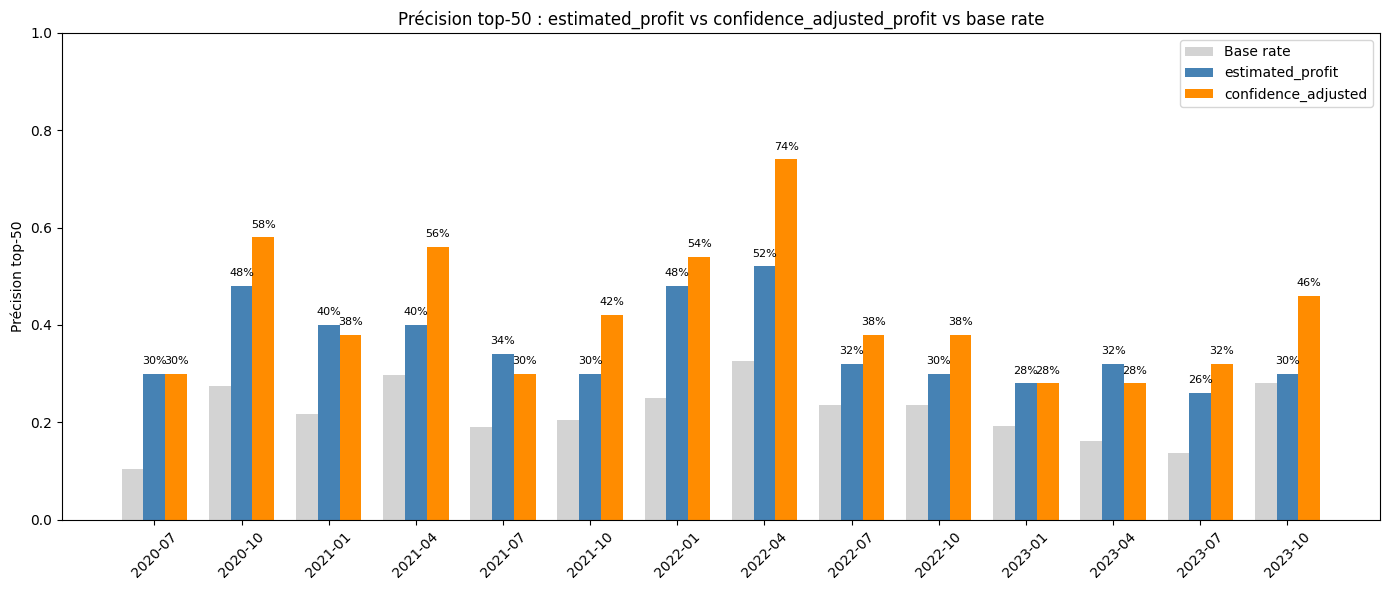


=== Résumé ===
Précision moyenne estimated_profit: 36%
Précision moyenne confidence_adjusted: 42%
Base rate moyen: 22%
Mois où CAP > EP: 9/14


In [36]:
import matplotlib.pyplot as plt
import numpy as np

test_months = [
    '2020-07', '2020-10', '2021-01', '2021-04', '2021-07',
    '2021-10', '2022-01', '2022-04', '2022-07', '2022-10',
    '2023-01', '2023-04', '2023-07', '2023-10'
]

results = []

for tm in test_months:
    print(f"Processing {tm}...")
    
    # Construire tous les features
    df = build_estimated_profit(tm)
    df = df.merge(build_scenario_consensus(tm), on=['EID', 'PEAKID', 'TARGET_MONTH'])
    df = df.merge(build_activation_impacts(tm), on=['EID', 'PEAKID', 'TARGET_MONTH'])
    df = df.merge(build_daily_signal(tm), on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')
    
    for col in ['daily_sum_abs_psd', 'daily_mean_activation', 'daily_max_activation',
                'daily_mean_trans_outage', 'daily_n_hours_active']:
        df[col] = df[col].fillna(0)
    
    df = build_derived_features(df)
    
    # Labels
    df['MONTH'] = tm
    profits = loader.get_price_cost_profit(filterdf=df[['EID', 'PEAKID', 'MONTH']])
    df = df.merge(profits[['EID', 'PEAKID', 'PROFIT']], on=['EID', 'PEAKID'], how='left')
    df['PROFIT'] = df['PROFIT'].fillna(0)
    df['profitable'] = (df['PROFIT'] > 0).astype(int)
    
    # Comparer les deux rankings
    top50_ep = df.nlargest(50, 'estimated_profit')
    top50_cap = df.nlargest(50, 'confidence_adjusted_profit')
    
    # Base rate (parmi les EID avec cost != 0)
    active = df[df['cost_proxy'] > 0]
    base_rate = active['profitable'].mean() if len(active) > 0 else 0
    
    results.append({
        'month': tm,
        'base_rate': base_rate,
        'prec_estimated_profit': top50_ep['profitable'].mean(),
        'prec_confidence_adjusted': top50_cap['profitable'].mean(),
    })
    
    print(f"  EP: {top50_ep['profitable'].mean():.0%} | CAP: {top50_cap['profitable'].mean():.0%} | Base: {base_rate:.0%}")

res = pd.DataFrame(results)

# === Visualisation ===
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(res))
width = 0.25

ax.bar(x - width, res['base_rate'], width, label='Base rate', color='lightgray')
ax.bar(x, res['prec_estimated_profit'], width, label='estimated_profit', color='steelblue')
ax.bar(x + width, res['prec_confidence_adjusted'], width, label='confidence_adjusted', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(res['month'], rotation=45)
ax.set_ylabel('Précision top-50')
ax.set_title('Précision top-50 : estimated_profit vs confidence_adjusted_profit vs base rate')
ax.legend()
ax.set_ylim(0, 1)

for i, row in res.iterrows():
    ax.text(i, row['prec_estimated_profit'] + 0.02, f"{row['prec_estimated_profit']:.0%}", ha='center', fontsize=8)
    ax.text(i + width, row['prec_confidence_adjusted'] + 0.02, f"{row['prec_confidence_adjusted']:.0%}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Résumé
print(f"\n=== Résumé ===")
print(f"Précision moyenne estimated_profit: {res['prec_estimated_profit'].mean():.0%}")
print(f"Précision moyenne confidence_adjusted: {res['prec_confidence_adjusted'].mean():.0%}")
print(f"Base rate moyen: {res['base_rate'].mean():.0%}")
print(f"Mois où CAP > EP: {(res['prec_confidence_adjusted'] > res['prec_estimated_profit']).sum()}/{len(res)}")

confidence_adjusted_profit prend ton estimated_profit et le réduit proportionnellement quand les 3 scénarios divergent. La formule est estimated_profit × (1 - coefficient_de_variation) : si les scénarios sont unanimes (CV=0), le profit reste intact; si ils divergent fortement (CV=1), le profit tombe à zéro.

CONCLUSION:

confidence_adjusted_profit domine

Sur 14 mois, il bat estimated_profit dans 9 mois, égalité dans 2, et perd dans seulement 3. Les gains sont souvent importants (74% vs 52% en avril 2022, 58% vs 48% en octobre 2020) tandis que les pertes sont marginales (38% vs 40% en janvier 2021).
Les deux battent systématiquement le base rate, confirmant que le signal est réel et robuste sur 3.5 ans de données.

Le pattern intéressant
Les meilleurs mois pour CAP sont ceux où les scénarios divergent beaucoup — exactement là où la pondération par la confiance fait la différence. Les mois où CAP ≈ EP (comme 2023-04 à 28%) sont probablement des mois où les scénarios s'accordent déjà, donc la pondération n'ajoute rien.

Implication pour le modèle
confidence_adjusted_profit devrait être un feature clé dans ton modèle, potentiellement plus prédictif que estimated_profit seul. oN GARDE Les deux,le modèle d'arbre saura quand utiliser l'un ou l'autre.

## Création du DATAFRAME DE FEATURES

In [51]:
def build_feature_dataframe(start_month: str, end_month: str) -> pd.DataFrame:
    """
    Construit le dataframe complet de features en itérant mois par mois.
    Chaque mois est traité indépendamment puis empilé verticalement.
    """
    
    all_months = pd.date_range(
        start=start_month + '-01',
        end=end_month + '-01',
        freq='MS'
    ).strftime('%Y-%m').tolist()
    
    chunks = []
    
    for target_month in all_months:
        print(f"Processing {target_month}...", end=' ')
        
        try:
            df = build_estimated_profit(target_month)
            df = df.merge(build_scenario_consensus(target_month), on=['EID', 'PEAKID', 'TARGET_MONTH'])
            df = df.merge(build_activation_impacts(target_month), on=['EID', 'PEAKID', 'TARGET_MONTH'])
            df = df.merge(build_daily_signal(target_month), on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')
            
            for col in ['daily_sum_abs_psd', 'daily_mean_activation', 'daily_max_activation',
                        'daily_mean_trans_outage', 'daily_n_hours_active']:
                df[col] = df[col].fillna(0)
            
            df = build_derived_features(df)
            
            chunks.append(df)
            print(f"OK — {len(df)} rows")
            
        except Exception as e:
            print(f"ERREUR — {e}")
            continue
    
    full_df = pd.concat(chunks, ignore_index=True)
    print(f"\nDataframe complet: {full_df.shape[0]} rows × {full_df.shape[1]} cols")
    print(f"Mois couverts: {full_df['TARGET_MONTH'].nunique()}")
    
    return full_df

DO IT

In [52]:
df = build_feature_dataframe('2020-02', '2024-12')
df.to_parquet('features_without_labels.parquet', index=False)

print(f"\nShape: {df.shape}")
print(f"Mois couverts: {df['TARGET_MONTH'].nunique()}")
print(f"Colonnes: {list(df.columns)}")

Processing 2020-02... OK — 9076 rows
Processing 2020-03... OK — 9076 rows
Processing 2020-04... OK — 9076 rows
Processing 2020-05... OK — 9076 rows
Processing 2020-06... OK — 9480 rows
Processing 2020-07... OK — 9272 rows
Processing 2020-08... OK — 9272 rows
Processing 2020-09... OK — 9272 rows
Processing 2020-10... OK — 9272 rows
Processing 2020-11... OK — 9272 rows
Processing 2020-12... OK — 10000 rows
Processing 2021-01... OK — 10348 rows
Processing 2021-02... OK — 10348 rows
Processing 2021-03... OK — 10348 rows
Processing 2021-04... OK — 10348 rows
Processing 2021-05... OK — 10348 rows
Processing 2021-06... OK — 11165 rows
Processing 2021-07... OK — 11164 rows
Processing 2021-08... OK — 11164 rows
Processing 2021-09... OK — 11164 rows
Processing 2021-10... OK — 11565 rows
Processing 2021-11... OK — 11560 rows
Processing 2021-12... OK — 11560 rows
Processing 2022-01... OK — 12038 rows
Processing 2022-02... OK — 12038 rows
Processing 2022-03... OK — 12038 rows
Processing 2022-04... 

## Add Y (labels of profitable =1 or 0)

In [53]:
def add_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute le label (profitable oui/non) et le profit réalisé.
    Utilise les données réalisées de M+1 (prix + coûts).
    
    Formule : PROFIT = |Σ prix horaires| - |C|
    Label = 1 si PROFIT > 0, sinon 0.
    
    Utilisé UNIQUEMENT pour le training/validation, jamais en production.
    """
    
    labels = []
    
    for target_month in df['TARGET_MONTH'].unique():
        print(f"Labels {target_month}...", end=' ')
        
        costs = duckdb.query(f"""
            SELECT EID, PEAKID, ABS(C) as COST
            FROM read_parquet({COST_FILES})
            WHERE MONTH = '{target_month}'
        """).to_df()
        
        prices = duckdb.query(f"""
            SELECT EID, PEAKID, ABS(SUM(PRICEREALIZED)) as PRICE
            FROM read_parquet({PRICE_FILES})
            WHERE strftime(DATETIME, '%Y-%m') = '{target_month}'
            GROUP BY EID, PEAKID
        """).to_df()
        
        monthly = costs.merge(prices, on=['EID', 'PEAKID'], how='outer').fillna(0)
        monthly['PROFIT'] = monthly['PRICE'] - monthly['COST']
        monthly['TARGET_MONTH'] = target_month
        labels.append(monthly)
        print("OK")
    
    labels_df = pd.concat(labels, ignore_index=True)
    labels_df['label'] = (labels_df['PROFIT'] > 0).astype(int)
    
    df = df.merge(
        labels_df[['EID', 'PEAKID', 'TARGET_MONTH', 'PROFIT', 'label']],
        on=['EID', 'PEAKID', 'TARGET_MONTH'],
        how='left'
    )
    
    df['PROFIT'] = df['PROFIT'].fillna(0)
    df['label'] = df['label'].fillna(0).astype(int)
    
    return df

Pour lancer

In [54]:
df = add_labels(df)
df.to_parquet('features_with_labels.parquet', index=False)

print(f"\nShape: {df.shape}")
print(f"Profitable: {df['label'].sum()} ({df['label'].mean():.2%})")
print(f"Mois couverts: {df['TARGET_MONTH'].nunique()}")

Labels 2020-02... OK
Labels 2020-03... OK
Labels 2020-04... OK
Labels 2020-05... OK
Labels 2020-06... OK
Labels 2020-07... OK
Labels 2020-08... OK
Labels 2020-09... OK
Labels 2020-10... OK
Labels 2020-11... OK
Labels 2020-12... OK
Labels 2021-01... OK
Labels 2021-02... OK
Labels 2021-03... OK
Labels 2021-04... OK
Labels 2021-05... OK
Labels 2021-06... OK
Labels 2021-07... OK
Labels 2021-08... OK
Labels 2021-09... OK
Labels 2021-10... OK
Labels 2021-11... OK
Labels 2021-12... OK
Labels 2022-01... OK
Labels 2022-02... OK
Labels 2022-03... OK
Labels 2022-04... OK
Labels 2022-05... OK
Labels 2022-06... OK
Labels 2022-07... OK
Labels 2022-08... OK
Labels 2022-09... OK
Labels 2022-10... OK
Labels 2022-11... OK
Labels 2022-12... OK
Labels 2023-01... OK
Labels 2023-02... OK
Labels 2023-03... OK
Labels 2023-04... OK
Labels 2023-05... OK
Labels 2023-06... OK
Labels 2023-07... OK
Labels 2023-08... OK
Labels 2023-09... OK
Labels 2023-10... OK
Labels 2023-11... OK
Labels 2023-12... OK
Labels 2024-0

## Modélisation 1 : Régresseur de profit + Walk-forward

le plus aligné avec les objectifs du challenge (maximiser F1 ET profit), le plus robuste (validation temporelle stricte), et le plus interprétable pour le jury (le modèle prédit directement le profit, pas une probabilité abstraite).

In [55]:
#Importer les librairies nécessaires
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [56]:
# === Charger le dataset ===
df = pd.read_parquet('features_with_labels.parquet')

# === Définir les features ===
FEATURE_COLS = [
    # Estimated profit
    'estimated_profit', 'mean_sum_abs_psm', 'cost_proxy',
    'sum_abs_psm_s1', 'sum_abs_psm_s2', 'sum_abs_psm_s3',
    # Consensus scénarios
    'psm_std_scenarios', 'psm_cv_scenarios',
    'estimated_profit_pessimistic', 'all_scenarios_profitable',
    # Activation + impacts
    'mean_activation', 'max_activation', 'pct_high_activation',
    'mean_wind', 'mean_solar', 'mean_hydro', 'mean_nonrenew',
    'mean_external', 'mean_transmission_outage', 'mean_load',
    'n_hours_active', 'impact_concentration',
    # Signal daily
    'daily_sum_abs_psd', 'daily_mean_activation', 'daily_max_activation',
    'daily_mean_trans_outage', 'daily_n_hours_active',
    # Dérivées
    'profit_cost_ratio', 'profit_per_active_hour',
    'confidence_adjusted_profit', 'monthly_daily_ratio',
    'month_sin', 'month_cos',
]

TARGET_COL = 'PROFIT'  # Régresseur — prédit le profit directement


# === Walk-forward ===
def walk_forward_predict(df: pd.DataFrame, 
                         start_predict: str = '2022-01',
                         min_train_months: int = 12) -> pd.DataFrame:
    """
    Walk-forward : pour chaque mois, entraîne sur tout le passé
    et prédit le mois courant.
    
    Args:
        df: DataFrame complet avec features et labels
        start_predict: premier mois à prédire
        min_train_months: minimum de mois d'entraînement avant de commencer
    
    Returns:
        DataFrame avec les prédictions pour chaque mois prédit
    """
    
    all_months = sorted(df['TARGET_MONTH'].unique())
    predict_months = [m for m in all_months if m >= start_predict]
    
    all_predictions = []
    
    for target_month in predict_months:
        # Train = tous les mois avant le mois courant
        train_months = [m for m in all_months if m < target_month]
        
        if len(train_months) < min_train_months:
            print(f"  {target_month}: skip (seulement {len(train_months)} mois de train)")
            continue
        
        train = df[df['TARGET_MONTH'].isin(train_months)]
        test = df[df['TARGET_MONTH'] == target_month]
        
        X_train = train[FEATURE_COLS]
        y_train = train[TARGET_COL]
        X_test = test[FEATURE_COLS]
        
        # --- LightGBM ---
        model = lgb.LGBMRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=50,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            verbose=-1,
        )
        
        model.fit(X_train, y_train)
        
        # Prédiction
        preds = model.predict(X_test)
        
        result = test[['EID', 'PEAKID', 'TARGET_MONTH', 'PROFIT', 'label']].copy()
        result['predicted_profit'] = preds
        all_predictions.append(result)
        
        # Évaluation rapide
        top50 = result.nlargest(50, 'predicted_profit')
        precision = top50['label'].mean()
        total_profit = top50['PROFIT'].sum()
        print(f"  {target_month}: top-50 précision={precision:.0%}, profit={total_profit:,.0f} "
              f"(train={len(train_months)} mois, {len(train):,} rows)")
    
    predictions = pd.concat(all_predictions, ignore_index=True)
    return predictions, model  # retourne aussi le dernier modèle pour SHAP


# === Lancer ===
print("Walk-forward en cours...\n")
predictions, last_model = walk_forward_predict(df, start_predict='2022-01')

# === Résumé ===
print(f"\n{'='*60}")
print(f"Mois prédits: {predictions['TARGET_MONTH'].nunique()}")

monthly = predictions.groupby('TARGET_MONTH').apply(
    lambda x: pd.Series({
        'precision_top50': x.nlargest(50, 'predicted_profit')['label'].mean(),
        'profit_top50': x.nlargest(50, 'predicted_profit')['PROFIT'].sum(),
    })
).reset_index()

print(f"Précision moyenne top-50: {monthly['precision_top50'].mean():.0%}")
print(f"Profit total: {monthly['profit_top50'].sum():,.0f}")

Walk-forward en cours...

  2022-01: top-50 précision=46%, profit=284,216 (train=23 mois, 233,226 rows)
  2022-02: top-50 précision=40%, profit=281,484 (train=24 mois, 245,264 rows)
  2022-03: top-50 précision=30%, profit=-8,806 (train=25 mois, 257,302 rows)
  2022-04: top-50 précision=48%, profit=452,893 (train=26 mois, 269,340 rows)
  2022-05: top-50 précision=48%, profit=219,959 (train=27 mois, 281,378 rows)
  2022-06: top-50 précision=30%, profit=118,497 (train=28 mois, 293,416 rows)
  2022-07: top-50 précision=52%, profit=176,441 (train=29 mois, 306,242 rows)
  2022-08: top-50 précision=56%, profit=192,909 (train=30 mois, 319,060 rows)
  2022-09: top-50 précision=48%, profit=41,091 (train=31 mois, 331,992 rows)
  2022-10: top-50 précision=24%, profit=-18,601 (train=32 mois, 344,782 rows)
  2022-11: top-50 précision=46%, profit=444,501 (train=33 mois, 357,572 rows)
  2022-12: top-50 précision=34%, profit=44,846 (train=34 mois, 370,362 rows)
  2023-01: top-50 précision=28%, profit=-

In [57]:
print(f"Avant filtre: {len(df):,} rows")
df_filtered = df[(df['mean_sum_abs_psm'] > 0) | (df['cost_proxy'] > 0)].copy()
print(f"Après filtre: {len(df_filtered):,} rows ({len(df_filtered)/len(df):.1%})")
print(f"Taux profitable avant: {df['label'].mean():.2%}")
print(f"Taux profitable après: {df_filtered['label'].mean():.2%}")

print("\nWalk-forward en cours...\n")
predictions_filtered, last_model = walk_forward_predict(df_filtered, start_predict='2022-01')

# Résumé comparatif
monthly = predictions_filtered.groupby('TARGET_MONTH').apply(
    lambda x: pd.Series({
        'precision_top50': x.nlargest(50, 'predicted_profit')['label'].mean(),
        'profit_top50': x.nlargest(50, 'predicted_profit')['PROFIT'].sum(),
    })
).reset_index()

print(f"\n{'='*60}")
print(f"Précision moyenne top-50: {monthly['precision_top50'].mean():.0%}")
print(f"Profit total: {monthly['profit_top50'].sum():,.0f}")

Avant filtre: 729,114 rows
Après filtre: 53,638 rows (7.4%)
Taux profitable avant: 2.73%
Taux profitable après: 16.59%

Walk-forward en cours...

  2022-01: top-50 précision=44%, profit=260,658 (train=23 mois, 16,228 rows)
  2022-02: top-50 précision=44%, profit=386,094 (train=24 mois, 17,000 rows)
  2022-03: top-50 précision=34%, profit=-105,709 (train=25 mois, 17,720 rows)
  2022-04: top-50 précision=44%, profit=311,305 (train=26 mois, 18,557 rows)
  2022-05: top-50 précision=50%, profit=213,582 (train=27 mois, 19,437 rows)
  2022-06: top-50 précision=38%, profit=190,324 (train=28 mois, 20,438 rows)
  2022-07: top-50 précision=50%, profit=149,369 (train=29 mois, 21,612 rows)
  2022-08: top-50 précision=52%, profit=178,332 (train=30 mois, 22,642 rows)
  2022-09: top-50 précision=42%, profit=24,623 (train=31 mois, 23,539 rows)
  2022-10: top-50 précision=26%, profit=-18,518 (train=32 mois, 24,777 rows)
  2022-11: top-50 précision=46%, profit=417,412 (train=33 mois, 25,617 rows)
  2022-

38% de précision c'est à peine mieux que ta baseline simple (confidence_adjusted_profit seul donnait ~38%). Le LightGBM n'exploite pas encore les features additionnels. Trois pistes d'amélioration :
1. Le top-50 fixe n'est pas optimal. Certains mois ont beaucoup d'opportunités, d'autres très peu. Teste un seuil adaptatif.
2. Le modèle n'a pas été tuné. Les hyperparamètres par défaut ne sont pas forcément les meilleurs.
3. On peut regarder le F1 et pas seulement la précision. Le challenge évalue aussi le recall.
Avant de tuner, regardons les feature importances pour comprendre ce que le modèle utilise

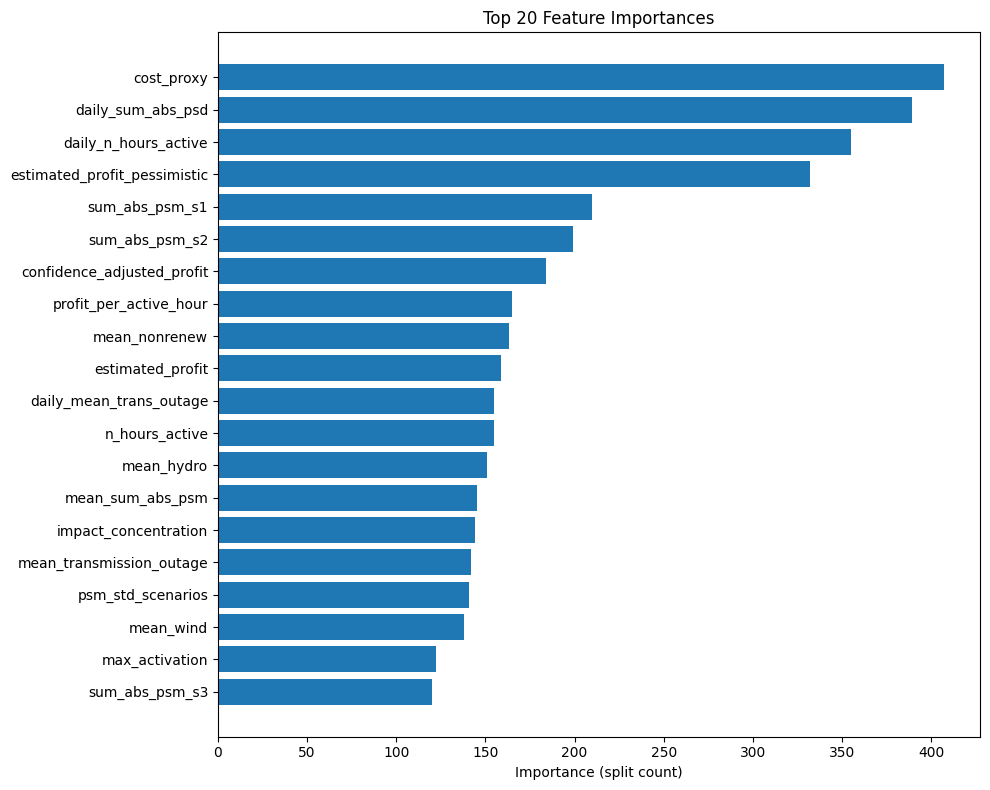

                     feature  importance
                  cost_proxy         407
           daily_sum_abs_psd         389
        daily_n_hours_active         355
estimated_profit_pessimistic         332
              sum_abs_psm_s1         210
              sum_abs_psm_s2         199
  confidence_adjusted_profit         184
      profit_per_active_hour         165
               mean_nonrenew         163
            estimated_profit         159
     daily_mean_trans_outage         155
              n_hours_active         155
                  mean_hydro         151
            mean_sum_abs_psm         145
        impact_concentration         144
    mean_transmission_outage         142
           psm_std_scenarios         141
                   mean_wind         138
              max_activation         122
              sum_abs_psm_s3         120
        daily_max_activation         118
       daily_mean_activation         114
            psm_cv_scenarios         105
               m

In [58]:
import lightgbm as lgb

# Feature importance du dernier modèle
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': last_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance['feature'][:20], importance['importance'][:20])
ax.set_xlabel('Importance (split count)')
ax.set_title('Top 20 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

Ce que ça veut dire pour la suite
La distribution est saine — pas de feature unique qui écrase tout. Le modèle exploite la complémentarité entre coût, simulations, signal daily et impacts. C'est un bon signe pour la généralisation.

### 1. regarder le F1-score et le recall LightGBMRegressor nr1

RÉSUMÉ PAR PEAK TYPE

ON:
  Precision: 36.8%
  Recall:    12.3%
  F1-score:  0.184
  TP=351, FP=603, FN=2503

OFF:
  Precision: 38.7%
  Recall:    11.1%
  F1-score:  0.172
  TP=327, FP=519, FN=2624

F1 FINAL (moyenne ON/OFF): 0.178
PROFIT TOTAL: 3,437,518


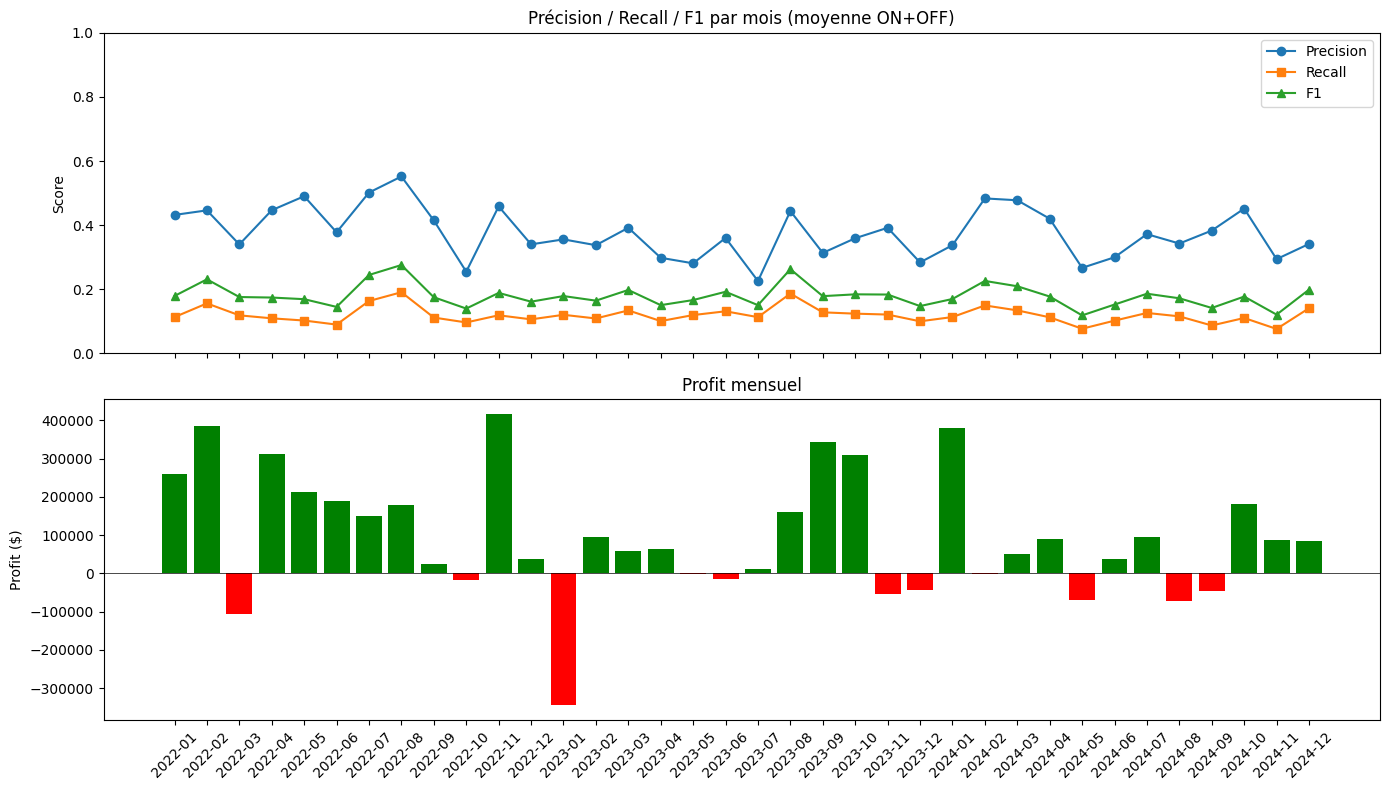

In [59]:
def evaluate_f1_profit(predictions: pd.DataFrame, df_full: pd.DataFrame, top_n: int = 50):
    """
    Évalue selon la grille du challenge :
    - Axe 1 : F1-score (séparé ON/OFF puis moyenné)
    - Axe 2 : Profit total net
    
    Args:
        predictions: sortie du walk-forward avec predicted_profit
        df_full: dataset complet filtré (pour connaître les FN)
        top_n: nombre d'opportunités sélectionnées par mois
    """
    
    monthly_metrics = []
    
    for target_month in sorted(predictions['TARGET_MONTH'].unique()):
        month_preds = predictions[predictions['TARGET_MONTH'] == target_month]
        month_full = df_full[df_full['TARGET_MONTH'] == target_month]
        
        # Sélection : top-N par predicted_profit
        selected = month_preds.nlargest(top_n, 'predicted_profit')
        selected_set = set(zip(selected['EID'], selected['PEAKID']))
        
        for peak in [0, 1]:
            peak_name = 'ON' if peak == 1 else 'OFF'
            
            # Sélectionnés pour ce peak
            sel_peak = selected[selected['PEAKID'] == peak]
            
            # Tous les profitables réels pour ce peak (= univers des FN potentiels)
            all_profitable = month_full[(month_full['PEAKID'] == peak) & (month_full['label'] == 1)]
            
            tp = sel_peak['label'].sum()
            fp = len(sel_peak) - tp
            fn = len(all_profitable) - tp  # profitables qu'on n'a pas sélectionnés
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            profit = sel_peak['PROFIT'].sum()
            
            monthly_metrics.append({
                'month': target_month,
                'peak': peak_name,
                'tp': tp, 'fp': fp, 'fn': fn,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'profit': profit,
                'n_selected': len(sel_peak),
                'n_profitable_total': len(all_profitable),
            })
    
    metrics = pd.DataFrame(monthly_metrics)
    
    # === Résumé par peak ===
    print("=" * 60)
    print("RÉSUMÉ PAR PEAK TYPE")
    print("=" * 60)
    for peak in ['ON', 'OFF']:
        m = metrics[metrics['peak'] == peak]
        total_tp = m['tp'].sum()
        total_fp = m['fp'].sum()
        total_fn = m['fn'].sum()
        
        agg_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        agg_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        agg_f1 = 2 * agg_precision * agg_recall / (agg_precision + agg_recall) if (agg_precision + agg_recall) > 0 else 0
        
        print(f"\n{peak}:")
        print(f"  Precision: {agg_precision:.1%}")
        print(f"  Recall:    {agg_recall:.1%}")
        print(f"  F1-score:  {agg_f1:.3f}")
        print(f"  TP={total_tp}, FP={total_fp}, FN={total_fn}")
    
    # F1 final = moyenne ON/OFF
    f1_on = metrics[metrics['peak'] == 'ON'].groupby('peak').apply(
        lambda x: 2 * (x['tp'].sum() / (x['tp'].sum() + x['fp'].sum())) * 
                  (x['tp'].sum() / (x['tp'].sum() + x['fn'].sum())) /
                  ((x['tp'].sum() / (x['tp'].sum() + x['fp'].sum())) + 
                   (x['tp'].sum() / (x['tp'].sum() + x['fn'].sum())))
    ).values[0]
    
    f1_off = metrics[metrics['peak'] == 'OFF'].groupby('peak').apply(
        lambda x: 2 * (x['tp'].sum() / (x['tp'].sum() + x['fp'].sum())) * 
                  (x['tp'].sum() / (x['tp'].sum() + x['fn'].sum())) /
                  ((x['tp'].sum() / (x['tp'].sum() + x['fp'].sum())) + 
                   (x['tp'].sum() / (x['tp'].sum() + x['fn'].sum())))
    ).values[0]
    
    print(f"\n{'='*60}")
    print(f"F1 FINAL (moyenne ON/OFF): {(f1_on + f1_off) / 2:.3f}")
    print(f"PROFIT TOTAL: {metrics['profit'].sum():,.0f}")
    
    # === Visualisation mensuelle ===
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    monthly_agg = metrics.groupby('month').agg(
        precision=('precision', 'mean'),
        recall=('recall', 'mean'),
        f1=('f1', 'mean'),
        profit=('profit', 'sum'),
    ).reset_index()
    
    axes[0].plot(monthly_agg['month'], monthly_agg['precision'], 'o-', label='Precision')
    axes[0].plot(monthly_agg['month'], monthly_agg['recall'], 's-', label='Recall')
    axes[0].plot(monthly_agg['month'], monthly_agg['f1'], '^-', label='F1')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Précision / Recall / F1 par mois (moyenne ON+OFF)')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=45)
    
    colors = ['green' if p > 0 else 'red' for p in monthly_agg['profit']]
    axes[1].bar(monthly_agg['month'], monthly_agg['profit'], color=colors)
    axes[1].set_ylabel('Profit ($)')
    axes[1].set_title('Profit mensuel')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].axhline(y=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return metrics

# === Lancer ===
metrics = evaluate_f1_profit(predictions_filtered, df_filtered, top_n=50)

Le problème : recall est trop bas (11-12%)
La précision est correcte (~38%) mais tu rates ~2500 opportunités profitables avec seulement 50 sélections par mois. Le F1 à 0.178 est tiré vers le bas par ce recall faible.

Mais c'est structurel
Avec la contrainte de 100 opportunités max par mois et des milliers de profitables dans l'univers filtré, le recall sera toujours bas. L'enjeu n'est pas d'atteindre un recall élevé — c'est impossible avec cette contrainte. L'enjeu est de maximiser F1 au point optimal entre précision et recall.


======================================== TOP-50 ========================================
RÉSUMÉ PAR PEAK TYPE

ON:
  Precision: 36.8%
  Recall:    12.3%
  F1-score:  0.184
  TP=351, FP=603, FN=2503

OFF:
  Precision: 38.7%
  Recall:    11.1%
  F1-score:  0.172
  TP=327, FP=519, FN=2624

F1 FINAL (moyenne ON/OFF): 0.178
PROFIT TOTAL: 3,437,518


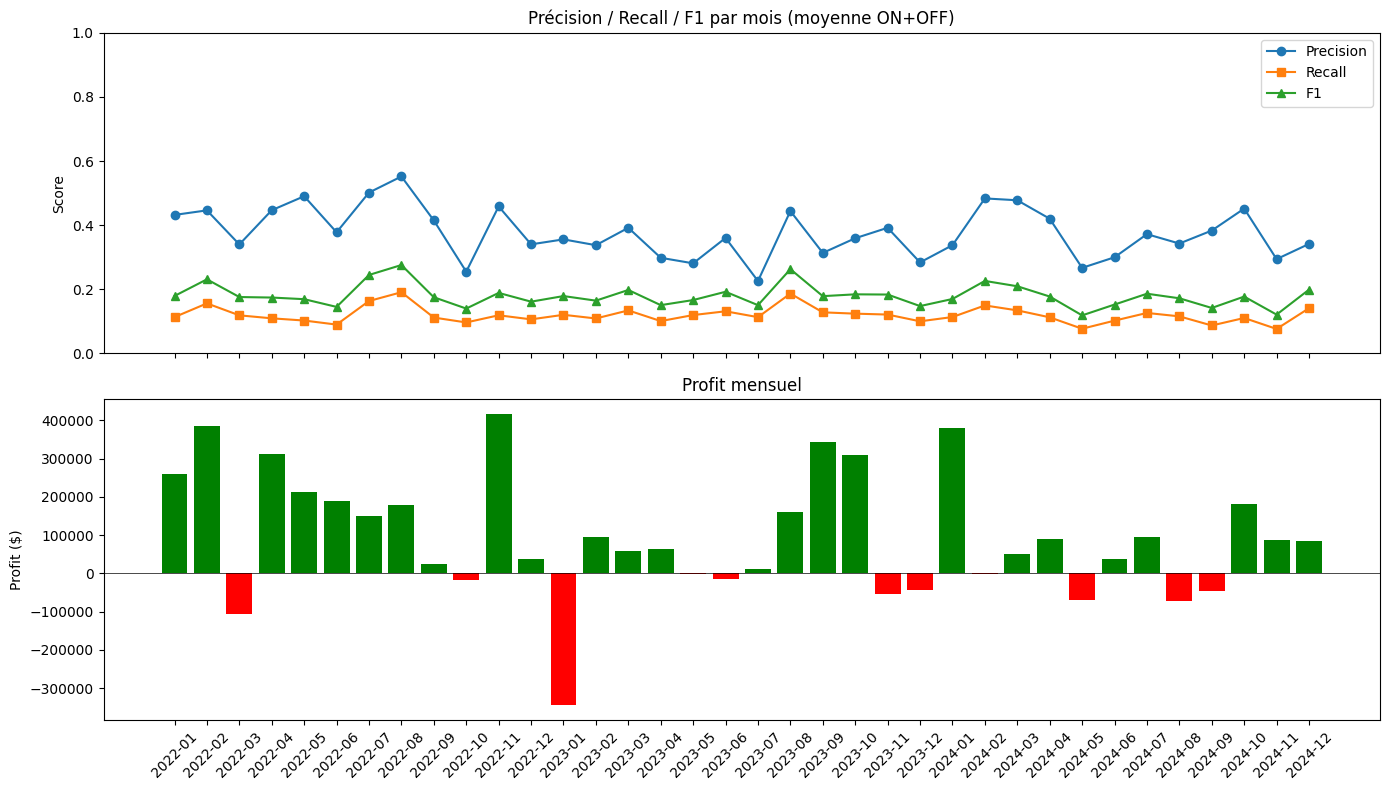


======================================== TOP-75 ========================================
RÉSUMÉ PAR PEAK TYPE

ON:
  Precision: 34.2%
  Recall:    17.0%
  F1-score:  0.227
  TP=486, FP=933, FN=2368

OFF:
  Precision: 34.8%
  Recall:    15.1%
  F1-score:  0.211
  TP=446, FP=835, FN=2505

F1 FINAL (moyenne ON/OFF): 0.219
PROFIT TOTAL: 3,959,162


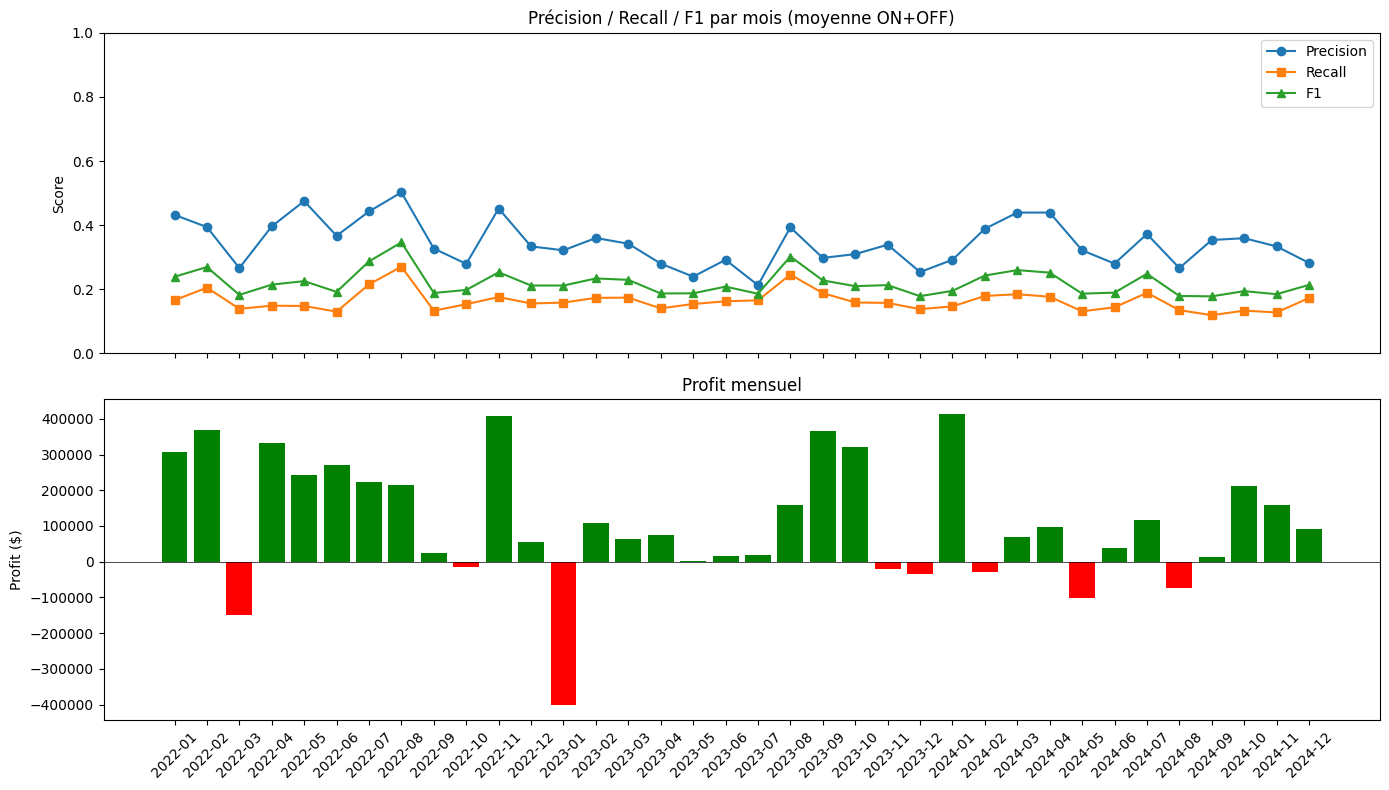


======================================== TOP-100 ========================================
RÉSUMÉ PAR PEAK TYPE

ON:
  Precision: 32.4%
  Recall:    21.5%
  F1-score:  0.258
  TP=613, FP=1281, FN=2241

OFF:
  Precision: 33.8%
  Recall:    19.6%
  F1-score:  0.248
  TP=577, FP=1129, FN=2374

F1 FINAL (moyenne ON/OFF): 0.253
PROFIT TOTAL: 4,503,185


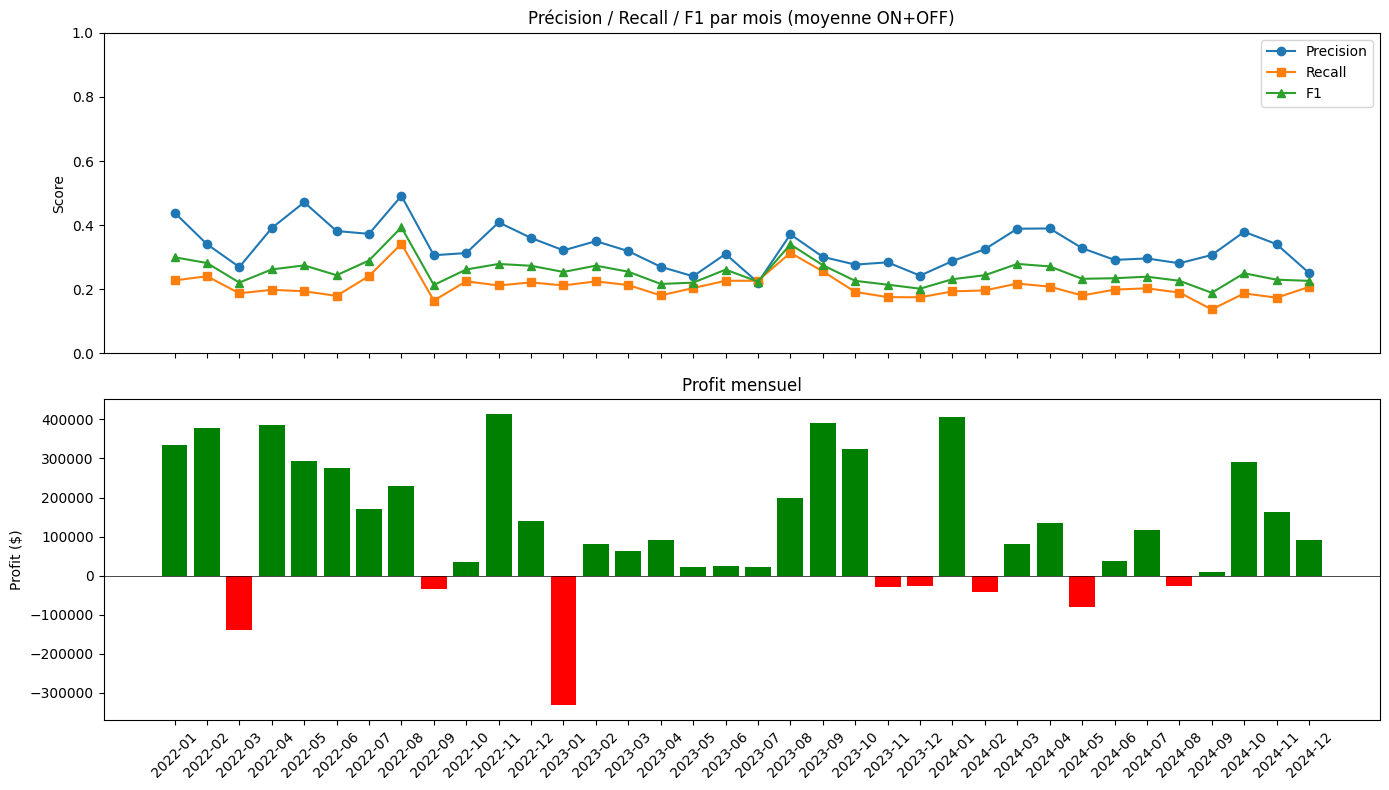

In [60]:
# Tester différents top_n
for n in [50, 75, 100]:
    print(f"\n{'='*40} TOP-{n} {'='*40}")
    _ = evaluate_f1_profit(predictions_filtered, df_filtered, top_n=n)

Les deux métriques du challenge (F1 et profit) s'améliorent en prenant plus d'opportunités. La précision baisse légèrement (38%→33%) mais le recall double (12%→21%), ce qui fait monter le F1 de 42%. Et le profit augmente de 1M$ parce que les opportunités au-delà du top-50 restent rentables en moyenne.
Conclusion : utilise top-100 systématiquement
C'est le max autorisé par les règles, et les deux axes d'évaluation en bénéficient. La légère perte de précision est largement compensée par le gain en recall et en profit.

## Séparation ON/OFF dans la sélection

Le F1 final est la moyenne du F1 ON et du F1 OFF. Actuellement on prends le top-100 global — si le modèle met 70 ON et 30 OFF dans le top-100, le recall OFF sera terrible et ça tire le F1 moyen vers le bas.

Il faut sélectionner les top-50 ON et les top-50 OFF séparément. Ça garantit une couverture équilibrée des deux peak types tout en restant dans la contrainte de 100 total.

In [61]:
def evaluate_balanced_selection(predictions: pd.DataFrame, df_full: pd.DataFrame):
    """
    Compare sélection globale vs sélection équilibrée ON/OFF.
    """
    
    results = {}
    
    for method in ['global_100', 'balanced_50_50', 'balanced_60_40', 'balanced_70_30']:
        monthly_metrics = []
        
        for target_month in sorted(predictions['TARGET_MONTH'].unique()):
            month_preds = predictions[predictions['TARGET_MONTH'] == target_month]
            month_full = df_full[df_full['TARGET_MONTH'] == target_month]
            
            # Sélection selon la méthode
            if method == 'global_100':
                selected = month_preds.nlargest(100, 'predicted_profit')
            elif method == 'balanced_50_50':
                on = month_preds[month_preds['PEAKID'] == 1].nlargest(50, 'predicted_profit')
                off = month_preds[month_preds['PEAKID'] == 0].nlargest(50, 'predicted_profit')
                selected = pd.concat([on, off])
            elif method == 'balanced_60_40':
                on = month_preds[month_preds['PEAKID'] == 1].nlargest(60, 'predicted_profit')
                off = month_preds[month_preds['PEAKID'] == 0].nlargest(40, 'predicted_profit')
                selected = pd.concat([on, off])
            elif method == 'balanced_70_30':
                on = month_preds[month_preds['PEAKID'] == 1].nlargest(70, 'predicted_profit')
                off = month_preds[month_preds['PEAKID'] == 0].nlargest(30, 'predicted_profit')
                selected = pd.concat([on, off])
            
            for peak in [0, 1]:
                sel_peak = selected[selected['PEAKID'] == peak]
                all_profitable = month_full[(month_full['PEAKID'] == peak) & (month_full['label'] == 1)]
                
                tp = sel_peak['label'].sum()
                fp = len(sel_peak) - tp
                fn = len(all_profitable) - tp
                
                monthly_metrics.append({
                    'month': target_month, 'peak': peak,
                    'tp': tp, 'fp': fp, 'fn': fn,
                    'profit': sel_peak['PROFIT'].sum(),
                })
        
        metrics = pd.DataFrame(monthly_metrics)
        
        # Calculer F1 par peak
        f1_scores = {}
        for peak in [0, 1]:
            m = metrics[metrics['peak'] == peak]
            total_tp = m['tp'].sum()
            total_fp = m['fp'].sum()
            total_fn = m['fn'].sum()
            prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
            rec = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
            f1_scores[peak] = {'precision': prec, 'recall': rec, 'f1': f1}
        
        final_f1 = (f1_scores[0]['f1'] + f1_scores[1]['f1']) / 2
        total_profit = metrics['profit'].sum()
        
        results[method] = {
            'f1_final': final_f1,
            'profit': total_profit,
            'f1_on': f1_scores[1]['f1'],
            'f1_off': f1_scores[0]['f1'],
            'prec_on': f1_scores[1]['precision'],
            'prec_off': f1_scores[0]['precision'],
            'rec_on': f1_scores[1]['recall'],
            'rec_off': f1_scores[0]['recall'],
        }
    
    # Affichage
    print(f"{'Method':<20} {'F1 Final':>10} {'F1 ON':>8} {'F1 OFF':>8} {'Profit':>12}")
    print("-" * 60)
    for method, r in results.items():
        print(f"{method:<20} {r['f1_final']:>10.3f} {r['f1_on']:>8.3f} {r['f1_off']:>8.3f} {r['profit']:>12,.0f}")
    
    print(f"\nDétail:")
    for method, r in results.items():
        print(f"\n{method}:")
        print(f"  ON  — prec={r['prec_on']:.1%} rec={r['rec_on']:.1%} f1={r['f1_on']:.3f}")
        print(f"  OFF — prec={r['prec_off']:.1%} rec={r['rec_off']:.1%} f1={r['f1_off']:.3f}")

# Lancer
evaluate_balanced_selection(predictions_filtered, df_filtered)

Method                 F1 Final    F1 ON   F1 OFF       Profit
------------------------------------------------------------
global_100                0.253    0.258    0.248    4,503,185
balanced_50_50            0.254    0.255    0.253    4,635,645
balanced_60_40            0.248    0.272    0.223    4,401,710
balanced_70_30            0.240    0.285    0.194    4,310,131

Détail:

global_100:
  ON  — prec=32.4% rec=21.5% f1=0.258
  OFF — prec=33.8% rec=19.6% f1=0.248

balanced_50_50:
  ON  — prec=33.0% rec=20.8% f1=0.255
  OFF — prec=33.3% rec=20.3% f1=0.253

balanced_60_40:
  ON  — prec=31.6% rec=23.9% f1=0.272
  OFF — prec=34.0% rec=16.6% f1=0.223

balanced_70_30:
  ON  — prec=30.4% rec=26.9% f1=0.285
  OFF — prec=36.3% rec=13.3% f1=0.194


Le F1 est quasi identique mais le profit gagne +130K$. Et surtout les F1 ON/OFF sont parfaitement équilibrés (0.255 vs 0.253), ce qui est important puisque le score final est leur moyenne — un déséquilibre pénalise toujours.
On utilisera le balanced_50_50 comme stratégie de sélection

## Tuning des hyperparamètres

LightGBM sur un dataset déséquilibré sont :

* n_estimators : nombre d'arbres
* max_depth : complexité de chaque arbre
* min_child_samples : régularisation contre l'overfitting
* scale_pos_weight : pondération des profitables

In [62]:
def walk_forward_with_params(df, params, start_predict='2022-01', min_train_months=12):
    """
    Walk-forward avec des hyperparamètres spécifiques.
    Retourne F1 final et profit total (balanced 50/50).
    """
    
    all_months = sorted(df['TARGET_MONTH'].unique())
    predict_months = [m for m in all_months if m >= start_predict]
    
    all_predictions = []
    
    for target_month in predict_months:
        train_months = [m for m in all_months if m < target_month]
        if len(train_months) < min_train_months:
            continue
        
        train = df[df['TARGET_MONTH'].isin(train_months)]
        test = df[df['TARGET_MONTH'] == target_month]
        
        model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
        model.fit(train[FEATURE_COLS], train[TARGET_COL])
        
        result = test[['EID', 'PEAKID', 'TARGET_MONTH', 'PROFIT', 'label']].copy()
        result['predicted_profit'] = model.predict(test[FEATURE_COLS])
        all_predictions.append(result)
    
    predictions = pd.concat(all_predictions, ignore_index=True)
    
    # Évaluation balanced 50/50
    monthly_metrics = []
    for target_month in predictions['TARGET_MONTH'].unique():
        month_preds = predictions[predictions['TARGET_MONTH'] == target_month]
        month_full = df[df['TARGET_MONTH'] == target_month]
        
        on = month_preds[month_preds['PEAKID'] == 1].nlargest(50, 'predicted_profit')
        off = month_preds[month_preds['PEAKID'] == 0].nlargest(50, 'predicted_profit')
        selected = pd.concat([on, off])
        
        for peak in [0, 1]:
            sel_peak = selected[selected['PEAKID'] == peak]
            all_profitable = month_full[(month_full['PEAKID'] == peak) & (month_full['label'] == 1)]
            tp = sel_peak['label'].sum()
            fp = len(sel_peak) - tp
            fn = len(all_profitable) - tp
            monthly_metrics.append({'peak': peak, 'tp': tp, 'fp': fp, 'fn': fn,
                                    'profit': sel_peak['PROFIT'].sum()})
    
    metrics = pd.DataFrame(monthly_metrics)
    
    f1_scores = []
    for peak in [0, 1]:
        m = metrics[metrics['peak'] == peak]
        t_tp, t_fp, t_fn = m['tp'].sum(), m['fp'].sum(), m['fn'].sum()
        prec = t_tp / (t_tp + t_fp) if (t_tp + t_fp) > 0 else 0
        rec = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f1_scores.append(f1)
    
    return (f1_scores[0] + f1_scores[1]) / 2, metrics['profit'].sum()


# === Grid search ===
param_grid = [
    # Baseline actuelle
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 50,
     'reg_alpha': 0.1, 'reg_lambda': 0.1},
    
    # Plus d'arbres, moins profonds
    {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 100,
     'reg_alpha': 0.5, 'reg_lambda': 0.5},
    
    # Plus profond, plus régularisé
    {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05,
     'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_samples': 30,
     'reg_alpha': 1.0, 'reg_lambda': 1.0},
    
    # Avec scale_pos_weight
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 50,
     'reg_alpha': 0.1, 'reg_lambda': 0.1,
     'scale_pos_weight': 5},
    
    # Agressif sur le déséquilibre
    {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 50,
     'reg_alpha': 0.5, 'reg_lambda': 0.5,
     'scale_pos_weight': 10},
    
    # Conservateur — forte régularisation
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
     'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_samples': 100,
     'reg_alpha': 2.0, 'reg_lambda': 2.0},
    
    # Beaucoup d'arbres, très shallow
    {'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.02,
     'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_samples': 80,
     'reg_alpha': 0.5, 'reg_lambda': 0.5},
]

print(f"Testing {len(param_grid)} configurations...\n")
print(f"{'#':<4} {'F1':>8} {'Profit':>12} {'Key params'}")
print("-" * 70)

results = []
for i, params in enumerate(param_grid):
    f1, profit = walk_forward_with_params(df_filtered, params)
    results.append({'idx': i, 'f1': f1, 'profit': profit, 'params': params})
    
    key = f"depth={params['max_depth']}, lr={params['learning_rate']}, n={params['n_estimators']}"
    if 'scale_pos_weight' in params:
        key += f", spw={params['scale_pos_weight']}"
    print(f"{i:<4} {f1:>8.3f} {profit:>12,.0f} {key}")

# Meilleur
best = max(results, key=lambda x: x['f1'])
print(f"\n{'='*70}")
print(f"MEILLEUR: config #{best['idx']} — F1={best['f1']:.3f}, Profit={best['profit']:,.0f}")
print(f"Params: {best['params']}")

Testing 7 configurations...

#          F1       Profit Key params
----------------------------------------------------------------------
0       0.254    4,635,645 depth=6, lr=0.05, n=300
1       0.257    5,149,453 depth=4, lr=0.03, n=500
2       0.256    4,623,636 depth=8, lr=0.05, n=300
3       0.254    4,635,645 depth=6, lr=0.05, n=300, spw=5
4       0.260    4,412,348 depth=6, lr=0.03, n=500, spw=10
5       0.261    5,238,761 depth=4, lr=0.05, n=200
6       0.260    4,921,724 depth=3, lr=0.02, n=800

MEILLEUR: config #5 — F1=0.261, Profit=5,238,761
Params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_samples': 100, 'reg_alpha': 2.0, 'reg_lambda': 2.0}


Les meilleures configs sont les plus simples et les plus régularisées :

#5 (gagnant) : depth=4, 200 arbres, forte régularisation (alpha=2, lambda=2) → F1=0.261, Profit=5.2M$
#1 : depth=4, 500 arbres, régularisation moyenne → F1=0.257, Profit=5.1M$
#6 : depth=3, 800 arbres → F1=0.260, Profit=4.9M$

les modèles simples généralisent mieux.

## Modélisation 2 : Régresseur de profit + Walk-forward + Après le fine-tuning

In [63]:
def walk_forward_predict(df: pd.DataFrame, 
                         start_predict: str = '2022-01',
                         min_train_months: int = 12) -> tuple:
    """
    Walk-forward : pour chaque mois, entraîne sur tout le passé
    et prédit le mois courant.
    
    Utilise les hyperparamètres optimisés (config #5).
    Sélection balanced 50/50 ON/OFF.
    """
    
    best_params = {
        'n_estimators': 200,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'min_child_samples': 100,
        'reg_alpha': 2.0,
        'reg_lambda': 2.0,
        'random_state': 42,
        'verbose': -1,
    }
    
    all_months = sorted(df['TARGET_MONTH'].unique())
    predict_months = [m for m in all_months if m >= start_predict]
    
    all_predictions = []
    
    for target_month in predict_months:
        train_months = [m for m in all_months if m < target_month]
        
        if len(train_months) < min_train_months:
            print(f"  {target_month}: skip ({len(train_months)} mois de train)")
            continue
        
        train = df[df['TARGET_MONTH'].isin(train_months)]
        test = df[df['TARGET_MONTH'] == target_month]
        
        model = lgb.LGBMRegressor(**best_params)
        model.fit(train[FEATURE_COLS], train[TARGET_COL])
        
        result = test[['EID', 'PEAKID', 'TARGET_MONTH', 'PROFIT', 'label']].copy()
        result['predicted_profit'] = model.predict(test[FEATURE_COLS])
        all_predictions.append(result)
        
        # Évaluation balanced 50/50
        on = result[result['PEAKID'] == 1].nlargest(50, 'predicted_profit')
        off = result[result['PEAKID'] == 0].nlargest(50, 'predicted_profit')
        selected = pd.concat([on, off])
        
        precision = selected['label'].mean()
        total_profit = selected['PROFIT'].sum()
        print(f"  {target_month}: précision={precision:.0%}, profit={total_profit:,.0f} "
              f"(train={len(train_months)} mois, {len(train):,} rows)")
    
    predictions = pd.concat(all_predictions, ignore_index=True)
    return predictions, model


# === Lancer ===
print("Walk-forward (params optimisés, balanced 50/50)...\n")
predictions_final, final_model = walk_forward_predict(df_filtered, start_predict='2022-01')

Walk-forward (params optimisés, balanced 50/50)...

  2022-01: précision=38%, profit=343,825 (train=23 mois, 16,228 rows)
  2022-02: précision=34%, profit=324,027 (train=24 mois, 17,000 rows)
  2022-03: précision=34%, profit=-142,802 (train=25 mois, 17,720 rows)
  2022-04: précision=36%, profit=467,156 (train=26 mois, 18,557 rows)
  2022-05: précision=50%, profit=341,735 (train=27 mois, 19,437 rows)
  2022-06: précision=37%, profit=300,083 (train=28 mois, 20,438 rows)
  2022-07: précision=35%, profit=97,929 (train=29 mois, 21,612 rows)
  2022-08: précision=46%, profit=277,631 (train=30 mois, 22,642 rows)
  2022-09: précision=33%, profit=109,567 (train=31 mois, 23,539 rows)
  2022-10: précision=39%, profit=85,107 (train=32 mois, 24,777 rows)
  2022-11: précision=45%, profit=415,292 (train=33 mois, 25,617 rows)
  2022-12: précision=33%, profit=104,719 (train=34 mois, 26,587 rows)
  2023-01: précision=34%, profit=-272,937 (train=35 mois, 27,554 rows)
  2023-02: précision=31%, profit=6,002

In [64]:
def evaluate_final(predictions: pd.DataFrame, df_full: pd.DataFrame):
    """
    Évaluation finale avec sélection balanced 50/50 ON/OFF.
    """
    
    monthly_metrics = []
    
    for target_month in sorted(predictions['TARGET_MONTH'].unique()):
        month_preds = predictions[predictions['TARGET_MONTH'] == target_month]
        month_full = df_full[df_full['TARGET_MONTH'] == target_month]
        
        # Sélection balanced 50/50
        on = month_preds[month_preds['PEAKID'] == 1].nlargest(50, 'predicted_profit')
        off = month_preds[month_preds['PEAKID'] == 0].nlargest(50, 'predicted_profit')
        selected = pd.concat([on, off])
        
        for peak in [0, 1]:
            sel_peak = selected[selected['PEAKID'] == peak]
            all_profitable = month_full[(month_full['PEAKID'] == peak) & (month_full['label'] == 1)]
            
            tp = sel_peak['label'].sum()
            fp = len(sel_peak) - tp
            fn = len(all_profitable) - tp
            
            monthly_metrics.append({
                'month': target_month, 'peak': 'ON' if peak == 1 else 'OFF',
                'tp': tp, 'fp': fp, 'fn': fn,
                'profit': sel_peak['PROFIT'].sum(),
            })
    
    metrics = pd.DataFrame(monthly_metrics)
    
    # F1 par peak
    print("=" * 60)
    for peak in ['ON', 'OFF']:
        m = metrics[metrics['peak'] == peak]
        t_tp, t_fp, t_fn = m['tp'].sum(), m['fp'].sum(), m['fn'].sum()
        prec = t_tp / (t_tp + t_fp) if (t_tp + t_fp) > 0 else 0
        rec = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        print(f"{peak}: Precision={prec:.1%} Recall={rec:.1%} F1={f1:.3f} (TP={t_tp} FP={t_fp} FN={t_fn})")
    
    # F1 final
    f1s = []
    for peak in [0, 1]:
        m = metrics[metrics['peak'] == ('ON' if peak == 1 else 'OFF')]
        t_tp, t_fp, t_fn = m['tp'].sum(), m['fp'].sum(), m['fn'].sum()
        prec = t_tp / (t_tp + t_fp) if (t_tp + t_fp) > 0 else 0
        rec = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f1s.append(f1)
    
    total_profit = metrics['profit'].sum()
    
    print(f"\n{'='*60}")
    print(f"F1 FINAL (moyenne ON/OFF): {sum(f1s)/2:.3f}")
    print(f"PROFIT TOTAL: {total_profit:,.0f}")
    
    return metrics

metrics_final = evaluate_final(predictions_final, df_filtered)

ON: Precision=34.3% Recall=21.6% F1=0.265 (TP=617 FP=1183 FN=2237)
OFF: Precision=33.8% Recall=20.6% F1=0.256 (TP=608 FP=1192 FN=2343)

F1 FINAL (moyenne ON/OFF): 0.261
PROFIT TOTAL: 5,238,761


## Modélisation 3 : Features historiques + Classifier vs Regressor

Le modèle actuel n'utilise que des features de simulation (PSM, activation, impacts). On ajoute des features historiques par (EID, PEAKID) pour capturer la persistance de profitabilité — un signal complémentaire aux simulations.

In [73]:
def build_historical_features(target_month: str) -> pd.DataFrame:
    """
    Pour un mois cible M+1, calcule des features historiques par (EID, PEAKID).
    
    Anti-leak : utilise uniquement les mois strictement < month_M (le mois avant le target).
    Month M est exclu car les prix réalisés complets ne sont pas disponibles au cutoff (7 du mois M).
    
    PROFIT = |Σ prix horaires| - |C| (même formule que add_labels)
    """
    
    target_date = pd.Timestamp(target_month + '-01')
    month_M = (target_date - relativedelta(months=1))
    month_M_str = month_M.strftime('%Y-%m')
    target_month_num = target_date.month
    
    # === 1. Récupérer tout l'historique des profits par (EID, PEAKID, MONTH) ===
    # Mois strictement avant M (anti-leak)
    costs_hist = duckdb.query(f"""
        SELECT EID, PEAKID, MONTH, ABS(C) as COST
        FROM read_parquet({COST_FILES})
        WHERE MONTH < '{month_M_str}'
    """).to_df()
    
    prices_hist = duckdb.query(f"""
        SELECT EID, PEAKID, strftime(DATETIME, '%Y-%m') as MONTH,
               ABS(SUM(PRICEREALIZED)) as PRICE
        FROM read_parquet({PRICE_FILES})
        WHERE strftime(DATETIME, '%Y-%m') < '{month_M_str}'
        GROUP BY EID, PEAKID, strftime(DATETIME, '%Y-%m')
    """).to_df()
    
    hist = costs_hist.merge(prices_hist, on=['EID', 'PEAKID', 'MONTH'], how='outer').fillna(0)
    hist['PROFIT'] = hist['PRICE'] - hist['COST']
    hist['profitable'] = (hist['PROFIT'] > 0).astype(int)
    
    if len(hist) == 0:
        return pd.DataFrame(columns=[
            'EID', 'PEAKID', 'TARGET_MONTH',
            'hist_win_rate', 'hist_n_months', 'hist_mean_profit', 'hist_std_profit',
            'hist_last_3m_win_rate', 'hist_last_6m_win_rate',
            'hist_consecutive_wins', 'hist_seasonal_win_rate',
            'hist_mean_cost', 'hist_mean_price',
        ])
    
    # === 2. Agrégats globaux par (EID, PEAKID) ===
    agg = hist.groupby(['EID', 'PEAKID']).agg(
        hist_win_rate=('profitable', 'mean'),
        hist_n_months=('MONTH', 'nunique'),
        hist_mean_profit=('PROFIT', 'mean'),
        hist_std_profit=('PROFIT', 'std'),
        hist_mean_cost=('COST', 'mean'),
        hist_mean_price=('PRICE', 'mean'),
    ).reset_index()
    agg['hist_std_profit'] = agg['hist_std_profit'].fillna(0)
    
    # === 3. Recency features : last 3 and 6 months ===
    hist_sorted = hist.sort_values('MONTH')
    
    def recency_win_rate(group, n_months):
        recent = group.tail(n_months)
        return recent['profitable'].mean() if len(recent) > 0 else 0
    
    last3 = hist_sorted.groupby(['EID', 'PEAKID']).apply(
        lambda g: recency_win_rate(g, 3), include_groups=False
    ).reset_index(name='hist_last_3m_win_rate')
    
    last6 = hist_sorted.groupby(['EID', 'PEAKID']).apply(
        lambda g: recency_win_rate(g, 6), include_groups=False
    ).reset_index(name='hist_last_6m_win_rate')
    
    # === 4. Consecutive wins (streak ending at most recent month) ===
    def consecutive_wins(group):
        profits = group.sort_values('MONTH')['profitable'].values
        streak = 0
        for val in reversed(profits):
            if val == 1:
                streak += 1
            else:
                break
        return streak
    
    streaks = hist_sorted.groupby(['EID', 'PEAKID']).apply(
        consecutive_wins, include_groups=False
    ).reset_index(name='hist_consecutive_wins')
    
    # === 5. Seasonal win rate (same calendar month) ===
    hist['month_num'] = pd.to_datetime(hist['MONTH'] + '-01').dt.month
    seasonal = hist[hist['month_num'] == target_month_num].groupby(['EID', 'PEAKID']).agg(
        hist_seasonal_win_rate=('profitable', 'mean'),
    ).reset_index()
    
    # === 6. Merge tout ===
    features = agg.merge(last3, on=['EID', 'PEAKID'], how='left')
    features = features.merge(last6, on=['EID', 'PEAKID'], how='left')
    features = features.merge(streaks, on=['EID', 'PEAKID'], how='left')
    features = features.merge(seasonal, on=['EID', 'PEAKID'], how='left')
    
    # Fill NaN (pas d'historique saisonnier = 0)
    for col in ['hist_last_3m_win_rate', 'hist_last_6m_win_rate', 
                'hist_consecutive_wins', 'hist_seasonal_win_rate']:
        features[col] = features[col].fillna(0)
    
    features['TARGET_MONTH'] = target_month
    
    return features

In [74]:
# Quick test sur un mois
df_hist_test = build_historical_features('2022-07')
print(f"Shape: {df_hist_test.shape}")
print(f"Colonnes: {list(df_hist_test.columns)}")
print(df_hist_test.describe().to_string())
print(f"\nhist_win_rate distribution:")
print(df_hist_test['hist_win_rate'].describe())

Shape: (4093, 13)
Colonnes: ['EID', 'PEAKID', 'hist_win_rate', 'hist_n_months', 'hist_mean_profit', 'hist_std_profit', 'hist_mean_cost', 'hist_mean_price', 'hist_last_3m_win_rate', 'hist_last_6m_win_rate', 'hist_consecutive_wins', 'hist_seasonal_win_rate', 'TARGET_MONTH']
               EID       PEAKID  hist_win_rate  hist_n_months  hist_mean_profit  hist_std_profit  hist_mean_cost  hist_mean_price  hist_last_3m_win_rate  hist_last_6m_win_rate  hist_consecutive_wins  hist_seasonal_win_rate
count  4093.000000  4093.000000    4093.000000    4093.000000       4093.000000      4093.000000     4093.000000      4093.000000            4093.000000            4093.000000            4093.000000             4093.000000
mean   5258.549475     0.526997       0.840063       3.984119        765.749755      1260.395323      430.770996      1196.520715               0.832315               0.838004               2.083802                0.124237
std    2313.344989     0.499332       0.298927       5.254

In [75]:
def build_feature_dataframe_v2(start_month: str, end_month: str) -> pd.DataFrame:
    """
    Construit le dataframe complet de features V2 : sim features + historical features.
    Même structure que build_feature_dataframe mais avec les features historiques en plus.
    """
    
    all_months = pd.date_range(
        start=start_month + '-01',
        end=end_month + '-01',
        freq='MS'
    ).strftime('%Y-%m').tolist()
    
    chunks = []
    
    for target_month in all_months:
        print(f"Processing {target_month}...", end=' ')
        
        try:
            # === Sim features (existants) ===
            df = build_estimated_profit(target_month)
            df = df.merge(build_scenario_consensus(target_month), on=['EID', 'PEAKID', 'TARGET_MONTH'])
            df = df.merge(build_activation_impacts(target_month), on=['EID', 'PEAKID', 'TARGET_MONTH'])
            df = df.merge(build_daily_signal(target_month), on=['EID', 'PEAKID', 'TARGET_MONTH'], how='left')
            
            for col in ['daily_sum_abs_psd', 'daily_mean_activation', 'daily_max_activation',
                        'daily_mean_trans_outage', 'daily_n_hours_active']:
                df[col] = df[col].fillna(0)
            
            df = build_derived_features(df)
            
            # === Historical features (nouveau) ===
            df_hist = build_historical_features(target_month)
            if len(df_hist) > 0:
                df = df.merge(
                    df_hist, 
                    on=['EID', 'PEAKID', 'TARGET_MONTH'], 
                    how='left'
                )
            else:
                # Premier mois : pas d'historique
                for col in ['hist_win_rate', 'hist_n_months', 'hist_mean_profit', 'hist_std_profit',
                           'hist_last_3m_win_rate', 'hist_last_6m_win_rate',
                           'hist_consecutive_wins', 'hist_seasonal_win_rate',
                           'hist_mean_cost', 'hist_mean_price']:
                    df[col] = 0
            
            # Fill NaN pour les EID sans historique
            hist_cols = ['hist_win_rate', 'hist_n_months', 'hist_mean_profit', 'hist_std_profit',
                        'hist_last_3m_win_rate', 'hist_last_6m_win_rate',
                        'hist_consecutive_wins', 'hist_seasonal_win_rate',
                        'hist_mean_cost', 'hist_mean_price']
            for col in hist_cols:
                if col in df.columns:
                    df[col] = df[col].fillna(0)
            
            chunks.append(df)
            print(f"OK — {len(df)} rows")
            
        except Exception as e:
            print(f"ERREUR — {e}")
            import traceback
            traceback.print_exc()
            continue
    
    full_df = pd.concat(chunks, ignore_index=True)
    print(f"\nDataframe V2 complet: {full_df.shape[0]} rows × {full_df.shape[1]} cols")
    print(f"Mois couverts: {full_df['TARGET_MONTH'].nunique()}")
    print(f"Nouvelles colonnes historiques: {[c for c in full_df.columns if c.startswith('hist_')]}")
    
    return full_df

In [76]:
# === Construire le dataset V2 avec features historiques ===
df_v2 = build_feature_dataframe_v2('2020-02', '2024-12')
df_v2 = add_labels(df_v2)
df_v2.to_parquet('features_v2_with_labels.parquet', index=False)

print(f"\nShape: {df_v2.shape}")
print(f"Label rate: {df_v2['label'].mean():.2%}")
print(f"Colonnes: {list(df_v2.columns)}")

Processing 2020-02... OK — 9076 rows
Processing 2020-03... OK — 9076 rows
Processing 2020-04... OK — 9076 rows
Processing 2020-05... OK — 9076 rows
Processing 2020-06... OK — 9480 rows
Processing 2020-07... OK — 9272 rows
Processing 2020-08... OK — 9272 rows
Processing 2020-09... OK — 9272 rows
Processing 2020-10... OK — 9272 rows
Processing 2020-11... OK — 9272 rows
Processing 2020-12... OK — 10000 rows
Processing 2021-01... OK — 10348 rows
Processing 2021-02... OK — 10348 rows
Processing 2021-03... OK — 10348 rows
Processing 2021-04... OK — 10348 rows
Processing 2021-05... OK — 10348 rows
Processing 2021-06... OK — 11165 rows
Processing 2021-07... OK — 11164 rows
Processing 2021-08... OK — 11164 rows
Processing 2021-09... OK — 11164 rows
Processing 2021-10... OK — 11565 rows
Processing 2021-11... OK — 11560 rows
Processing 2021-12... OK — 11560 rows
Processing 2022-01... OK — 12038 rows
Processing 2022-02... OK — 12038 rows
Processing 2022-03... OK — 12038 rows
Processing 2022-04... 

In [77]:
import lightgbm as lgb
import numpy as np

# === Charger le dataset V2 ===
df_v2 = pd.read_parquet('features_v2_with_labels.parquet')

# === Filtre identique à la V1 ===
df_v2_filtered = df_v2[(df_v2['mean_sum_abs_psm'] > 0) | (df_v2['cost_proxy'] > 0)].copy()
print(f"Avant filtre: {len(df_v2):,} rows")
print(f"Après filtre: {len(df_v2_filtered):,} rows ({len(df_v2_filtered)/len(df_v2):.1%})")
print(f"Taux profitable: {df_v2_filtered['label'].mean():.2%}")

# === Features V2 ===
FEATURE_COLS_V2 = [
    # === HISTORICAL (complementary signal) ===
    'hist_win_rate', 'hist_n_months', 'hist_mean_profit', 'hist_std_profit',
    'hist_last_3m_win_rate', 'hist_last_6m_win_rate',
    'hist_consecutive_wins', 'hist_seasonal_win_rate',
    'hist_mean_cost', 'hist_mean_price',
    # === EXPLICIT ===
    'PEAKID',
    # === SIM-BASED (existing) ===
    'estimated_profit', 'mean_sum_abs_psm', 'cost_proxy',
    'sum_abs_psm_s1', 'sum_abs_psm_s2', 'sum_abs_psm_s3',
    'psm_std_scenarios', 'psm_cv_scenarios',
    'estimated_profit_pessimistic', 'all_scenarios_profitable',
    'mean_activation', 'max_activation', 'pct_high_activation',
    'mean_wind', 'mean_solar', 'mean_hydro', 'mean_nonrenew',
    'mean_external', 'mean_transmission_outage', 'mean_load',
    'n_hours_active', 'impact_concentration',
    'daily_sum_abs_psd', 'daily_mean_activation', 'daily_max_activation',
    'daily_mean_trans_outage', 'daily_n_hours_active',
    'profit_cost_ratio', 'profit_per_active_hour',
    'confidence_adjusted_profit', 'monthly_daily_ratio',
    'month_sin', 'month_cos',
]

# === Walk-forward comparatif : 3 approches ===
def walk_forward_compare(df, feature_cols, start_predict='2022-01', min_train_months=12):
    """
    Compare Regressor, Classifier, et Classifier+time-decay
    sur les mêmes données avec balanced 50/50 selection.
    """
    
    all_months = sorted(df['TARGET_MONTH'].unique())
    predict_months = [m for m in all_months if m >= start_predict]
    month_indices = {m: i for i, m in enumerate(all_months)}
    
    best_params = {
        'n_estimators': 200,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'min_child_samples': 100,
        'reg_alpha': 2.0,
        'reg_lambda': 2.0,
        'random_state': 42,
        'verbose': -1,
    }
    
    approaches = {
        'A_regressor': {'type': 'regressor', 'time_decay': False},
        'B_classifier': {'type': 'classifier', 'time_decay': False},
        'C_classifier_decay': {'type': 'classifier', 'time_decay': True},
    }
    
    all_predictions = {name: [] for name in approaches}
    
    for target_month in predict_months:
        train_months = [m for m in all_months if m < target_month]
        
        if len(train_months) < min_train_months:
            continue
        
        train = df[df['TARGET_MONTH'].isin(train_months)]
        test = df[df['TARGET_MONTH'] == target_month]
        
        X_train = train[feature_cols]
        X_test = test[feature_cols]
        
        for name, config in approaches.items():
            if config['type'] == 'regressor':
                model = lgb.LGBMRegressor(**best_params)
                y_train = train['PROFIT']
                model.fit(X_train, y_train)
                scores = model.predict(X_test)
            else:
                model = lgb.LGBMClassifier(**best_params)
                y_train = train['label']
                
                if config['time_decay']:
                    weights = train['TARGET_MONTH'].map(
                        lambda m: 0.95 ** (month_indices[target_month] - month_indices[m])
                    )
                    model.fit(X_train, y_train, sample_weight=weights)
                else:
                    model.fit(X_train, y_train)
                
                scores = model.predict_proba(X_test)[:, 1]
            
            result = test[['EID', 'PEAKID', 'TARGET_MONTH', 'PROFIT', 'label']].copy()
            result['predicted_profit'] = scores
            all_predictions[name].append(result)
        
        # Progress
        on_scores = all_predictions['A_regressor'][-1]
        sel_on = on_scores[on_scores['PEAKID'] == 1].nlargest(50, 'predicted_profit')
        sel_off = on_scores[on_scores['PEAKID'] == 0].nlargest(50, 'predicted_profit')
        sel = pd.concat([sel_on, sel_off])
        print(f"  {target_month}: regressor prec={sel['label'].mean():.0%} "
              f"(train={len(train_months)} mois)")
    
    # === Évaluation de chaque approche ===
    print(f"\n{'='*70}")
    print(f"{'Approche':<25} {'F1 Final':>10} {'F1 ON':>8} {'F1 OFF':>8} {'Profit':>14}")
    print("-" * 70)
    
    results = {}
    for name, preds_list in all_predictions.items():
        predictions = pd.concat(preds_list, ignore_index=True)
        
        monthly_metrics = []
        for target_month in predictions['TARGET_MONTH'].unique():
            month_preds = predictions[predictions['TARGET_MONTH'] == target_month]
            month_full = df[df['TARGET_MONTH'] == target_month]
            
            on = month_preds[month_preds['PEAKID'] == 1].nlargest(50, 'predicted_profit')
            off = month_preds[month_preds['PEAKID'] == 0].nlargest(50, 'predicted_profit')
            selected = pd.concat([on, off])
            
            for peak in [0, 1]:
                sel_peak = selected[selected['PEAKID'] == peak]
                all_profitable = month_full[(month_full['PEAKID'] == peak) & (month_full['label'] == 1)]
                tp = sel_peak['label'].sum()
                fp = len(sel_peak) - tp
                fn = len(all_profitable) - tp
                monthly_metrics.append({
                    'peak': peak, 'tp': tp, 'fp': fp, 'fn': fn,
                    'profit': sel_peak['PROFIT'].sum()
                })
        
        metrics = pd.DataFrame(monthly_metrics)
        
        f1s = []
        details = {}
        for peak in [0, 1]:
            m = metrics[metrics['peak'] == peak]
            t_tp, t_fp, t_fn = m['tp'].sum(), m['fp'].sum(), m['fn'].sum()
            prec = t_tp / (t_tp + t_fp) if (t_tp + t_fp) > 0 else 0
            rec = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
            f1s.append(f1)
            peak_name = 'ON' if peak == 1 else 'OFF'
            details[peak_name] = {'prec': prec, 'rec': rec, 'f1': f1,
                                  'tp': t_tp, 'fp': t_fp, 'fn': t_fn}
        
        f1_final = sum(f1s) / 2
        profit = metrics['profit'].sum()
        
        print(f"{name:<25} {f1_final:>10.3f} {f1s[1]:>8.3f} {f1s[0]:>8.3f} {profit:>14,.0f}")
        
        results[name] = {
            'predictions': predictions,
            'f1_final': f1_final,
            'profit': profit,
            'details': details,
        }
    
    # Détails du meilleur
    best_name = max(results, key=lambda k: results[k]['f1_final'])
    print(f"\n{'='*70}")
    print(f"MEILLEUR: {best_name} — F1={results[best_name]['f1_final']:.3f}, "
          f"Profit={results[best_name]['profit']:,.0f}")
    for peak_name, d in results[best_name]['details'].items():
        print(f"  {peak_name}: Precision={d['prec']:.1%} Recall={d['rec']:.1%} "
              f"F1={d['f1']:.3f} (TP={d['tp']} FP={d['fp']} FN={d['fn']})")
    
    print(f"\nBaseline V1: F1=0.261, Profit=5,238,761")
    
    return results

# === Lancer ===
results_v2 = walk_forward_compare(df_v2_filtered, FEATURE_COLS_V2)

Avant filtre: 729,114 rows
Après filtre: 53,638 rows (7.4%)
Taux profitable: 16.59%
  2022-01: regressor prec=60% (train=23 mois)
  2022-02: regressor prec=42% (train=24 mois)
  2022-03: regressor prec=35% (train=25 mois)
  2022-04: regressor prec=47% (train=26 mois)
  2022-05: regressor prec=55% (train=27 mois)
  2022-06: regressor prec=41% (train=28 mois)
  2022-07: regressor prec=41% (train=29 mois)
  2022-08: regressor prec=53% (train=30 mois)
  2022-09: regressor prec=50% (train=31 mois)
  2022-10: regressor prec=40% (train=32 mois)
  2022-11: regressor prec=48% (train=33 mois)
  2022-12: regressor prec=36% (train=34 mois)
  2023-01: regressor prec=46% (train=35 mois)
  2023-02: regressor prec=46% (train=36 mois)
  2023-03: regressor prec=40% (train=37 mois)
  2023-04: regressor prec=30% (train=38 mois)
  2023-05: regressor prec=28% (train=39 mois)
  2023-06: regressor prec=36% (train=40 mois)
  2023-07: regressor prec=27% (train=41 mois)
  2023-08: regressor prec=39% (train=42 mo

Feature importances pour: B_classifier



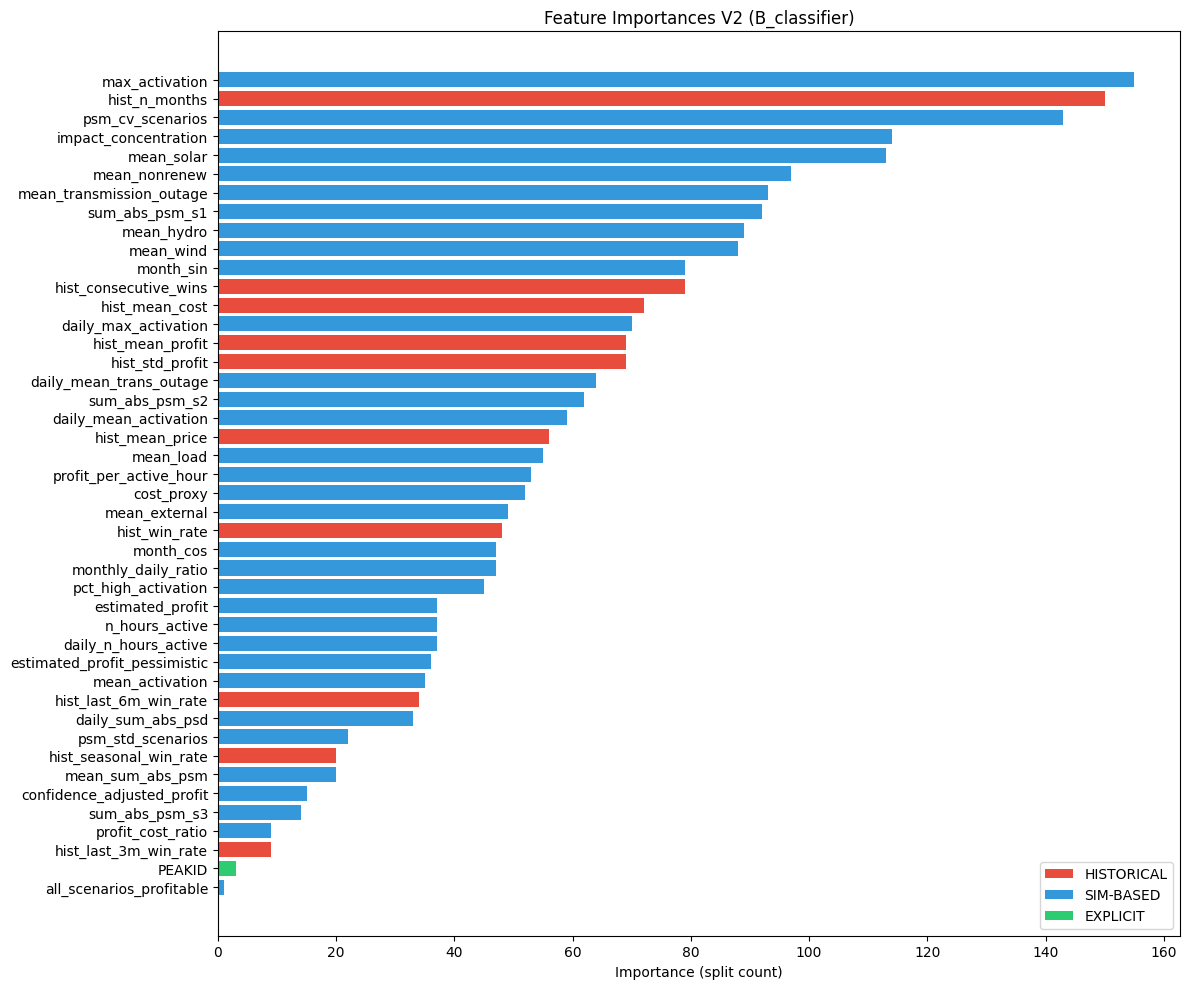

                     feature  importance   category
              max_activation         155  SIM-BASED
               hist_n_months         150 HISTORICAL
            psm_cv_scenarios         143  SIM-BASED
        impact_concentration         114  SIM-BASED
                  mean_solar         113  SIM-BASED
               mean_nonrenew          97  SIM-BASED
    mean_transmission_outage          93  SIM-BASED
              sum_abs_psm_s1          92  SIM-BASED
                  mean_hydro          89  SIM-BASED
                   mean_wind          88  SIM-BASED
                   month_sin          79  SIM-BASED
       hist_consecutive_wins          79 HISTORICAL
              hist_mean_cost          72 HISTORICAL
        daily_max_activation          70  SIM-BASED
            hist_mean_profit          69 HISTORICAL
             hist_std_profit          69 HISTORICAL
     daily_mean_trans_outage          64  SIM-BASED
              sum_abs_psm_s2          62  SIM-BASED
       daily

In [78]:
# === Feature importance du meilleur modèle V2 ===
# Re-entraîner un seul modèle sur tout le train pour voir les importances

best_approach = max(results_v2, key=lambda k: results_v2[k]['f1_final'])
print(f"Feature importances pour: {best_approach}\n")

all_months = sorted(df_v2_filtered['TARGET_MONTH'].unique())
train = df_v2_filtered[df_v2_filtered['TARGET_MONTH'] < '2023-12']

if 'classifier' in best_approach:
    model_final = lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, min_child_samples=100,
        reg_alpha=2.0, reg_lambda=2.0, random_state=42, verbose=-1,
    )
    model_final.fit(train[FEATURE_COLS_V2], train['label'])
else:
    model_final = lgb.LGBMRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, min_child_samples=100,
        reg_alpha=2.0, reg_lambda=2.0, random_state=42, verbose=-1,
    )
    model_final.fit(train[FEATURE_COLS_V2], train['PROFIT'])

importance = pd.DataFrame({
    'feature': FEATURE_COLS_V2,
    'importance': model_final.feature_importances_
}).sort_values('importance', ascending=False)

# Séparer historiques vs sim
importance['category'] = importance['feature'].apply(
    lambda f: 'HISTORICAL' if f.startswith('hist_') else ('EXPLICIT' if f == 'PEAKID' else 'SIM-BASED')
)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 10))
colors = importance['category'].map({
    'HISTORICAL': '#e74c3c',
    'SIM-BASED': '#3498db', 
    'EXPLICIT': '#2ecc71'
})
ax.barh(importance['feature'], importance['importance'], color=colors)
ax.set_xlabel('Importance (split count)')
ax.set_title(f'Feature Importances V2 ({best_approach})')
ax.invert_yaxis()

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='HISTORICAL'),
    Patch(facecolor='#3498db', label='SIM-BASED'),
    Patch(facecolor='#2ecc71', label='EXPLICIT'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

# Résumé par catégorie
print(f"\nImportance totale par catégorie:")
print(importance.groupby('category')['importance'].sum().sort_values(ascending=False).to_string())

Le classifier est mieux aligné avec le F1. Le regressor optimise l'erreur quadratique sur le profit — il s'acharne à prédire la magnitude exacte, ce qui n'est pas ce qu'on évalue.

Le classifier optimise directement la frontière profitable/non-profitable.

Les features historiques apportent un vrai signal. hist_n_months est #2 en importance, hist_consecutive_wins et hist_mean_cost sont dans le top 15. Le modèle apprend que les EID avec un long historique d'activité et des streaks de profitabilité sont de meilleurs candidats. Quand on testait hist_profit_rate seul, le signal était faible — mais dans un modèle avec d'autres features, l'historique enrichi se combine efficacement.

Observations sur le feature importance
max_activation prend la tête. Il était #19 dans la V1 et maintenant #1. Le classifier l'utilise différemment du regressor — probablement comme seuil de filtrage plutôt que comme prédicteur de magnitude.

cost_proxy chute de #1 à #23. Le classifier n'a plus besoin de s'appuyer autant sur le coût brut car les features historiques (hist_mean_cost, hist_mean_profit) capturent la même information de manière plus riche.

Les features redondants se confirment. all_scenarios_profitable (1), profit_cost_ratio (9), sum_abs_psm_s3 (14) — candidates à la suppression pour simplifier le modèle.

## Quick validation regarding some features

In [65]:
# Vérifier l'affirmation "zero-sim = 91% profitable"
# Parmi les EID avec cost != 0 mais PSM = 0, combien sont profitables ?

test_month = '2022-07'
df_check = df[df['TARGET_MONTH'] == test_month].copy()

zero_sim = df_check[(df_check['mean_sum_abs_psm'] == 0) & (df_check['cost_proxy'] > 0)]
nonzero_sim = df_check[(df_check['mean_sum_abs_psm'] > 0) & (df_check['cost_proxy'] > 0)]
no_cost = df_check[(df_check['mean_sum_abs_psm'] > 0) & (df_check['cost_proxy'] == 0)]

print(f"Zero sim + cost>0: {len(zero_sim)} EID, profitable={zero_sim['label'].mean():.0%}")
print(f"Nonzero sim + cost>0: {len(nonzero_sim)} EID, profitable={nonzero_sim['label'].mean():.0%}")
print(f"Nonzero sim + cost=0: {len(no_cost)} EID, profitable={no_cost['label'].mean():.0%}")

Zero sim + cost>0: 89 EID, profitable=17%
Nonzero sim + cost>0: 72 EID, profitable=32%
Nonzero sim + cost=0: 869 EID, profitable=14%
